**Universidad Tecnológica Nacional — Facultad Regional Buenos Aires**  
Centro de e-Learning · Secretaría de Cultura y Extensión Universitaria  
Diplomatura en Ciencia de Datos y Análisis Avanzado  
**Módulo 10 — Proyecto Final Integrador**

# Evaluación de la tasa ajustada por riesgo como indicador de desempeño hospitalario

**Aplicación al análisis de sepsis posoperatoria en hospitales de California · 2019–2023**

**Autor:** Lisandro Chiavassa  
**Año:** 2026


## Objetivo y alcance

Este análisis explora la distribución de tasas de sepsis postoperatoria en hospitales de California durante 2019–2023, con el fin de identificar patrones de desempeño institucional que pudieran orientar decisiones de auditoría y control de calidad hospitalaria.

## Por qué este dataset

Tres dimensiones simultáneas: geografía, tiempo y desempeño hospitalario.

El dataset utilizado se titula **Postoperative Sepsis Outcomes for Elective Surgeries in California Hospitals**. Está publicado por el **California Department of Health Care Access and Information** en **California Open Data**. El recurso de datos usado dentro de esa publicación se denomina **Agency for Healthcare Research and Quality Postoperative Sepsis Rates 2019–2023**.

Es un dataset hospitalario real, de acceso público, con descarga en formato CSV y consulta desde la página del dataset. Figura con licencia **Creative Commons Attribution**.

Ruta pública de acceso al dataset:
**California Open Data → Postoperative Sepsis Outcomes for Elective Surgeries in California Hospitals → Agency for Healthcare Research and Quality Postoperative Sepsis Rates 2019–2023 → Download CSV**.

Enlace público:
https://lab.data.ca.gov/dataset/postoperative-sepsis-outcomes-for-elective-surgeries-in-california-hospitals

El período abarca una de las mayores alteraciones de la actividad sanitaria mundial por la pandemia COVID-19. Esto imprime al análisis dinamismo, incertidumbre y desafíos metodológicos.

## Foco del análisis

Estudio de la tasa de infecciones postoperatorias en hospitales de California durante 2019–2023, un período marcado por alta volatilidad debido a la pandemia COVID-19.

## Hipótesis

- Las cirugías programadas cayeron en 2020 por la suspensión de cirugías programadas durante la pandemia.
- La tasa ajustada de sepsis podía modificarse porque el denominador operativo bajó y el perfil de pacientes operados podía haber cambiado hacia mayor gravedad o complejidad.


## Glosario de términos médicos y de referencia

**Postoperative Sepsis** — Sepsis postoperatoria.
Infección grave que se desarrolla después de una cirugía y que
compromete el funcionamiento de órganos vitales.

**Elective Surgical Discharges** — Egresos quirúrgicos electivos.
Cantidad de pacientes dados de alta después de una cirugía programada,
es decir, no urgente.

**Risk-adjusted Postoperative Sepsis Rate** — Tasa ajustada por riesgo
de sepsis postoperatoria.
Mide cuántas infecciones graves tuvo un hospital comparado con las que
le correspondían según el perfil de sus pacientes.
Descuenta edad, enfermedades previas y tipo de cirugía.
Es la variable de mayor complejidad analítica del dataset.

**OSHPDID** — Identificador único del hospital en el sistema
de salud de California (Office of Statewide Health Planning
and Development).

**County** — Condado. División administrativa del estado de California,
equivalente aproximado a un departamento o provincia.

**Performance Rating** — Calificación de desempeño del hospital
respecto al promedio estatal: Above Average, Average, Below Average.


## Requisito de datos, ruta y replicabilidad

Este análisis utiliza el dataset **Postoperative Sepsis Outcomes for Elective Surgeries in California Hospitals**, publicado por el **California Department of Health Care Access and Information** en **California Open Data**.

Dentro de esa publicación, el archivo trabajado corresponde al recurso **Agency for Healthcare Research and Quality Postoperative Sepsis Rates 2019–2023**.

El dataset es de acceso público. La página oficial permite descarga del archivo en formato CSV y consulta desde la interfaz de datos. La licencia consignada por California Open Data es **Creative Commons Attribution**.

Ruta pública de acceso:
1. Entrar a California Open Data.
2. Buscar **Postoperative Sepsis Outcomes for Elective Surgeries in California Hospitals**.
3. Abrir el recurso **Agency for Healthcare Research and Quality Postoperative Sepsis Rates 2019–2023**.
4. Descargar el archivo en formato CSV.

Enlace público:
https://lab.data.ca.gov/dataset/postoperative-sepsis-outcomes-for-elective-surgeries-in-california-hospitals

Para reproducir el análisis de este notebook:
1. Descargar el archivo CSV desde la página oficial indicada.
2. Guardarlo con el nombre `2019-2023-postoperative-sepsis-rates.csv`.
3. Colocar ese archivo en la misma carpeta que este notebook. Si se ejecuta en Google Colab, también puede colocarse en la raíz de Google Drive.
4. Ejecutar la celda de configuración de ruta del dataset y continuar con la carga de librerías.


In [1]:
# Configuración de ruta del dataset
# Ruta recomendada para la entrega: colocar el archivo CSV en la misma carpeta que este notebook.
# Nombre esperado del archivo: 2019-2023-postoperative-sepsis-rates.csv

from pathlib import Path

DATASET_FILE = '2019-2023-postoperative-sepsis-rates.csv'

# Primero se busca el archivo en la carpeta local del notebook.
local_path = Path(DATASET_FILE)

# Si se ejecuta en Google Colab, también se busca en la raíz de Google Drive.
drive_path = Path('/content/drive/MyDrive') / DATASET_FILE

if local_path.exists():
    DATASET_PATH = local_path
elif drive_path.exists():
    DATASET_PATH = drive_path
else:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        if drive_path.exists():
            DATASET_PATH = drive_path
        else:
            raise FileNotFoundError
    except Exception:
        raise FileNotFoundError(
            f'No se encontró {DATASET_FILE}. Coloque el archivo en la misma carpeta del notebook '
            f'o en /content/drive/MyDrive/{DATASET_FILE} si usa Google Colab.'
        )

print(f'Ruta del dataset utilizada: {DATASET_PATH}')


Ruta del dataset utilizada: 2019-2023-postoperative-sepsis-rates.csv


In [2]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(DATASET_PATH, encoding='latin1')
df.head()


,Year,County,OSHPDID,Hospital Name,Postoperative Sepsis Cases,Elective Surgical Discharges,Risk-adjusted Postoperative Sepsis Rate,Risk-adjustedAveragePerformanceAverageRating,Longitude,Latitude
0,2019,STATEWIDE,NaN,NaN,1328,299027,0.44,NaN,NaN,NaN
1,2019,Alameda,106010735.0,Alameda Hospital,0,84,0.00,Average,-122.253991,37.76266
2,2019,Alameda,106010739.0,Alta Bates Summit Medical Center  Alta Bates ...,3,733,0.65,Average,-122.25743,37.85645
3,2019,Alameda,106010846.0,Highland Hospital,0,77,0.00,Average,-122.23138,37.79925
4,2019,Alameda,106010937.0,Alta Bates Summit Medical Center,16,1464,1.01,Below Average,-122.26257,37.82106


In [4]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(1475, 10)
Year                                              int64
County                                              str
OSHPDID                                         float64
Hospital Name                                       str
Postoperative Sepsis Cases                        int64
Elective Surgical Discharges                      int64
Risk-adjusted Postoperative Sepsis Rate         float64
Risk-adjustedAveragePerformanceAverageRating        str
Longitude                                           str
Latitude                                            str
dtype: object
Year                                            0
County                                          0
OSHPDID                                         5
Hospital Name                                   5
Postoperative Sepsis Cases                      0
Elective Surgical Discharges                    0
Risk-adjusted Postoperative Sepsis Rate         0
Risk-adjustedAveragePerformanceAverageRating    4
Longitude      

## Clasificación de variables — por qué este paso

Python no puede calcular con palabras, solo con números.
Antes de cualquier análisis necesitamos saber exactamente
qué tipo de dato es cada variable para tratarla correctamente.

Performance Rating es ordinal, no nominal.
Above Average es objetivamente mejor que Below Average.
Si se convierte a número sin respetar ese orden, el modelo
trata las tres categorías como si fueran iguales entre sí.
Se pierde la jerarquía clínica real — y ese error
se arrastra a todo el análisis posterior.


In [5]:
# Clasificación de variables
clasificacion = {
    'Continuas': [
        'Longitude',
        'Latitude'
    ],
    'Discretas': [
        'Postoperative Sepsis Cases',
        'Elective Surgical Discharges'
    ],
    'Nominales': [
        'County',
        'Hospital Name'
    ],
    'Ordinales': [
        'Risk-adjustedAveragePerformanceAverageRating'
    ]
}

# Variable objetivo del análisis
target = 'Risk-adjusted Postoperative Sepsis Rate'

# Excluidas del análisis univariado cuantitativo
# OSHPDID es un identificador nominal — etiqueta, no variable de análisis
# Year funciona como factor de segmentación temporal, no como magnitud continua
excluir = ['OSHPDID', 'Year']

print(f"Variable objetivo: {target}")
print(f"Excluidas del univariado cuantitativo: {excluir}")

Variable objetivo: Risk-adjusted Postoperative Sepsis Rate
Excluidas del univariado cuantitativo: ['OSHPDID', 'Year']


In [6]:
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
print(df[['Longitude', 'Latitude']].dtypes)

Longitude    float64
Latitude     float64
dtype: object


In [7]:
# Etapa 3 — Eliminación de filas STATEWIDE
# Las filas agregadas a nivel estado se identifican por County == 'STATEWIDE'.
# El Rating de esas filas viene vacío (NaN), por eso el filtro va sobre County.
df = df[df['County'] != 'STATEWIDE']
df = df.reset_index(drop=True)

print(f"Filas restantes: {df.shape[0]}")
print(f"Nulos restantes:\n{df.isnull().sum()}")

Filas restantes: 1470
Nulos restantes:
Year                                            0
County                                          0
OSHPDID                                         0
Hospital Name                                   0
Postoperative Sepsis Cases                      0
Elective Surgical Discharges                    0
Risk-adjusted Postoperative Sepsis Rate         0
Risk-adjustedAveragePerformanceAverageRating    0
Longitude                                       0
Latitude                                        0
dtype: int64


## Etapa 3 — Valores faltantes

Al revisar los nulos aparecen valores ausentes en cinco columnas:
OSHPDID, Hospital Name, Performance Rating, Longitude y Latitude.
Todos tienen el mismo origen: las filas STATEWIDE, que no corresponden
a un hospital individual sino al agregado estatal.
Al eliminarlas por la columna County, esas filas salen del dataset
y el análisis queda trabajando solo con hospitales.


In [8]:
df.describe()

,Year,OSHPDID,Postoperative Sepsis Cases,Elective Surgical Discharges,Risk-adjusted Postoperative Sepsis Rate,Longitude,Latitude
count,1470.000000,1.470000e+03,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,2020.978231,1.062841e+08,3.844218,802.406803,0.503728,-119.666333,35.848149
std,1.415008,1.366632e+05,7.556609,1065.316553,0.866982,2.066129,2.240163
min,2019.000000,1.060107e+08,0.000000,3.000000,0.000000,-124.195140,32.619090
25%,2020.000000,1.061904e+08,0.000000,128.000000,0.000000,-121.802080,33.971448
50%,2021.000000,1.063012e+08,1.000000,458.500000,0.350000,-118.967222,34.584375
75%,2022.000000,1.063809e+08,4.000000,1024.750000,0.650000,-117.988950,37.790962
max,2023.000000,1.065810e+08,77.000000,8720.000000,13.890000,-114.595600,41.773659


### Verificación complementaria de calidad — duplicados y años por hospital

Antes de agregar por hospital conviene confirmar dos cosas: que no haya filas repetidas y cuántos años aporta cada hospital. Un hospital con menos de cinco años tiene menos oportunidades de repetir una calificación, y eso se tiene en cuenta al leer el índice de persistencia.

In [9]:
# Filas duplicadas y combinaciones hospital-año repetidas
print("Filas duplicadas exactas:", df.duplicated().sum())
print("Combinaciones hospital-año repetidas:", df.duplicated(subset=['OSHPDID', 'Year']).sum())

# Años con datos por hospital
años_por_hospital = df.groupby('OSHPDID')['Year'].count()
print("\nHospitales según cantidad de años con datos:")
print(años_por_hospital.value_counts().sort_index())
print("\nHospitales con menos de 5 años:", (años_por_hospital < 5).sum(), "de", len(años_por_hospital))

Filas duplicadas exactas: 0
Combinaciones hospital-año repetidas: 0

Hospitales según cantidad de años con datos:
Year
1     13
2      5
3      6
4     11
5    277
Name: count, dtype: int64

Hospitales con menos de 5 años: 35 de 312


In [10]:
print(df.columns.tolist())

['Year', 'County', 'OSHPDID', 'Hospital Name', 'Postoperative Sepsis Cases', 'Elective Surgical Discharges', 'Risk-adjusted Postoperative Sepsis Rate', 'Risk-adjustedAveragePerformanceAverageRating', 'Longitude', 'Latitude']


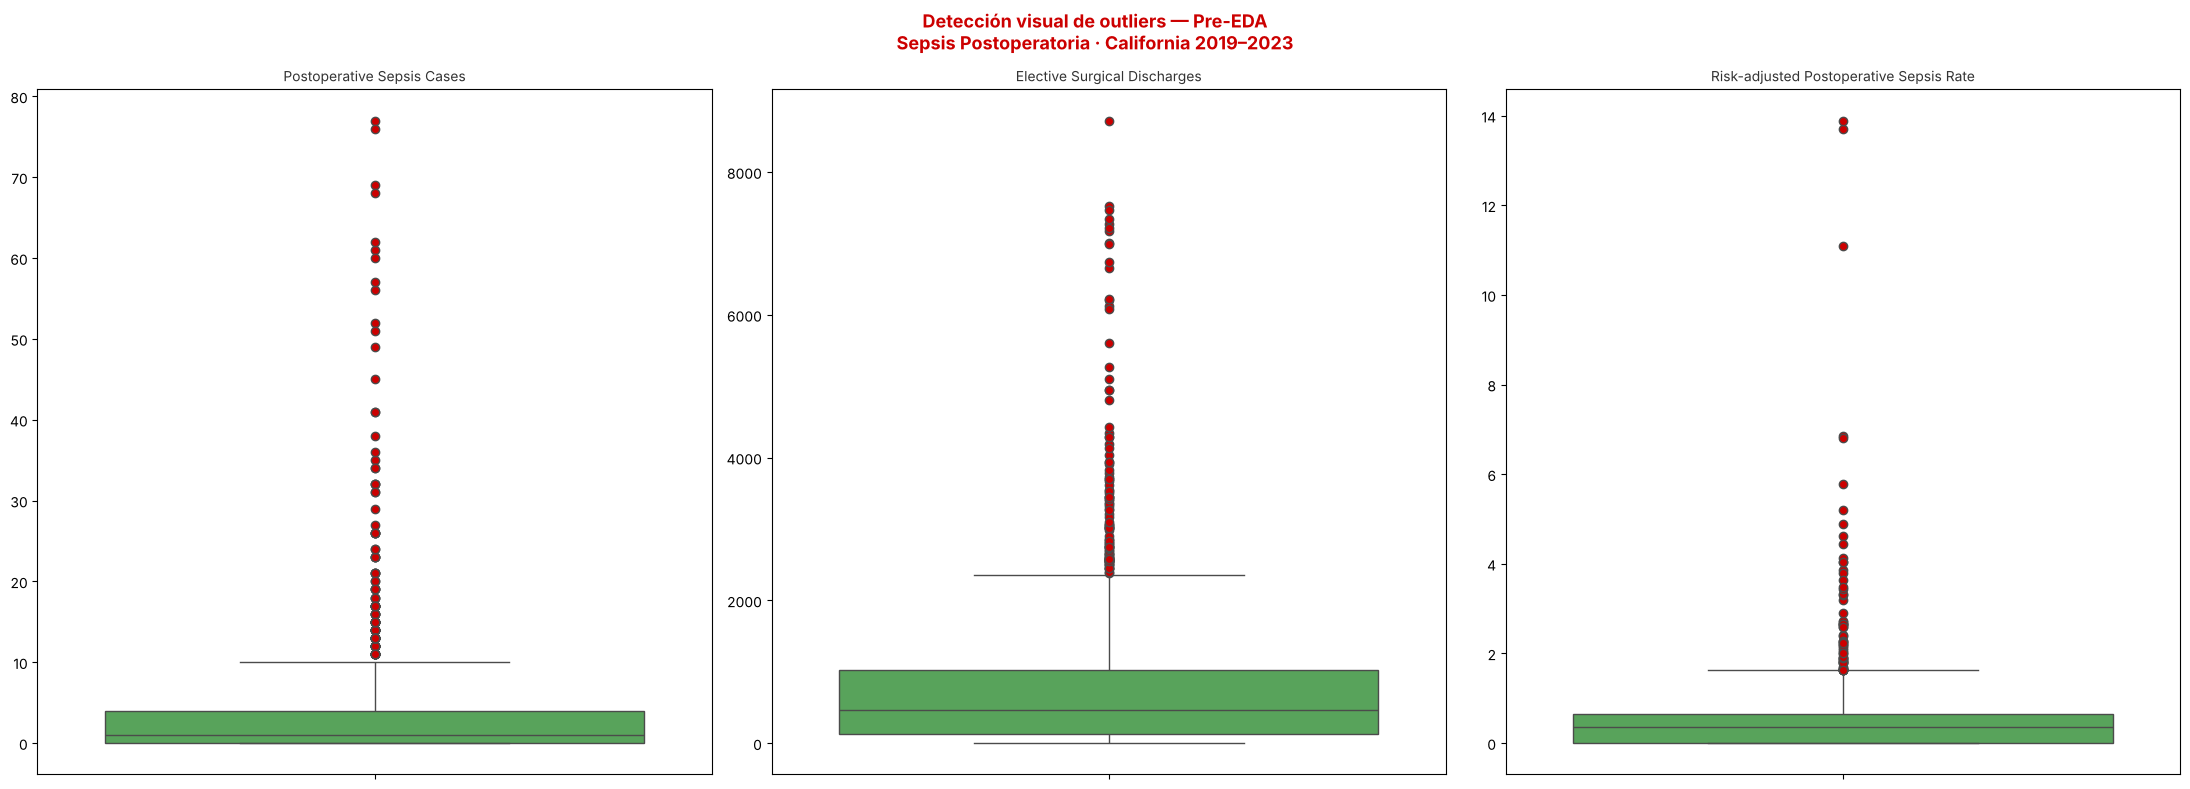

In [11]:
# ============================================================
# DETECCIÓN VISUAL DE OUTLIERS — Pre-EDA
# Metodología: John Tukey (EDA clásico)
# Principio: ver los datos antes de asumir algo sobre ellos
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

fig.suptitle(
    "Detección visual de outliers — Pre-EDA\nSepsis Postoperatoria · California 2019–2023",
    fontsize=13, fontweight="bold", color="#CC0000"
)

variables = [
    "Postoperative Sepsis Cases",
    "Elective Surgical Discharges",
    "Risk-adjusted Postoperative Sepsis Rate"
]

for ax, col in zip(axes, variables):
    sns.boxplot(
        y=df[col],
        ax=ax,
        color="#4CAF50",
        flierprops=dict(
            marker="o",
            markerfacecolor="#CC0000",
            markersize=6,
            linestyle="none"
        )
    )
    ax.set_title(col, fontsize=10, color="#333333")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


## Análisis de gráficos — primeros datos relevantes

La tasa ajustada es la variable de mayor complejidad analítica
del dataset.

El tercer gráfico muestra una distribución concentrada en valores
bajos con presencia de outliers por encima de la caja —
hospitales con tasas de sepsis ajustada superiores al rango esperado.
Estos casos requieren investigación específica en el análisis posterior.

**Nota metodológica:** se decide aplicar un ajuste de escala visual
(set_ylim) para enfocar el gráfico en el rango donde se concentra
el 90% de los datos. Esto no modifica los valores ni el cálculo
estadístico — permite visualizar la caja y los bigotes con claridad
sin distorsión por valores extremos.


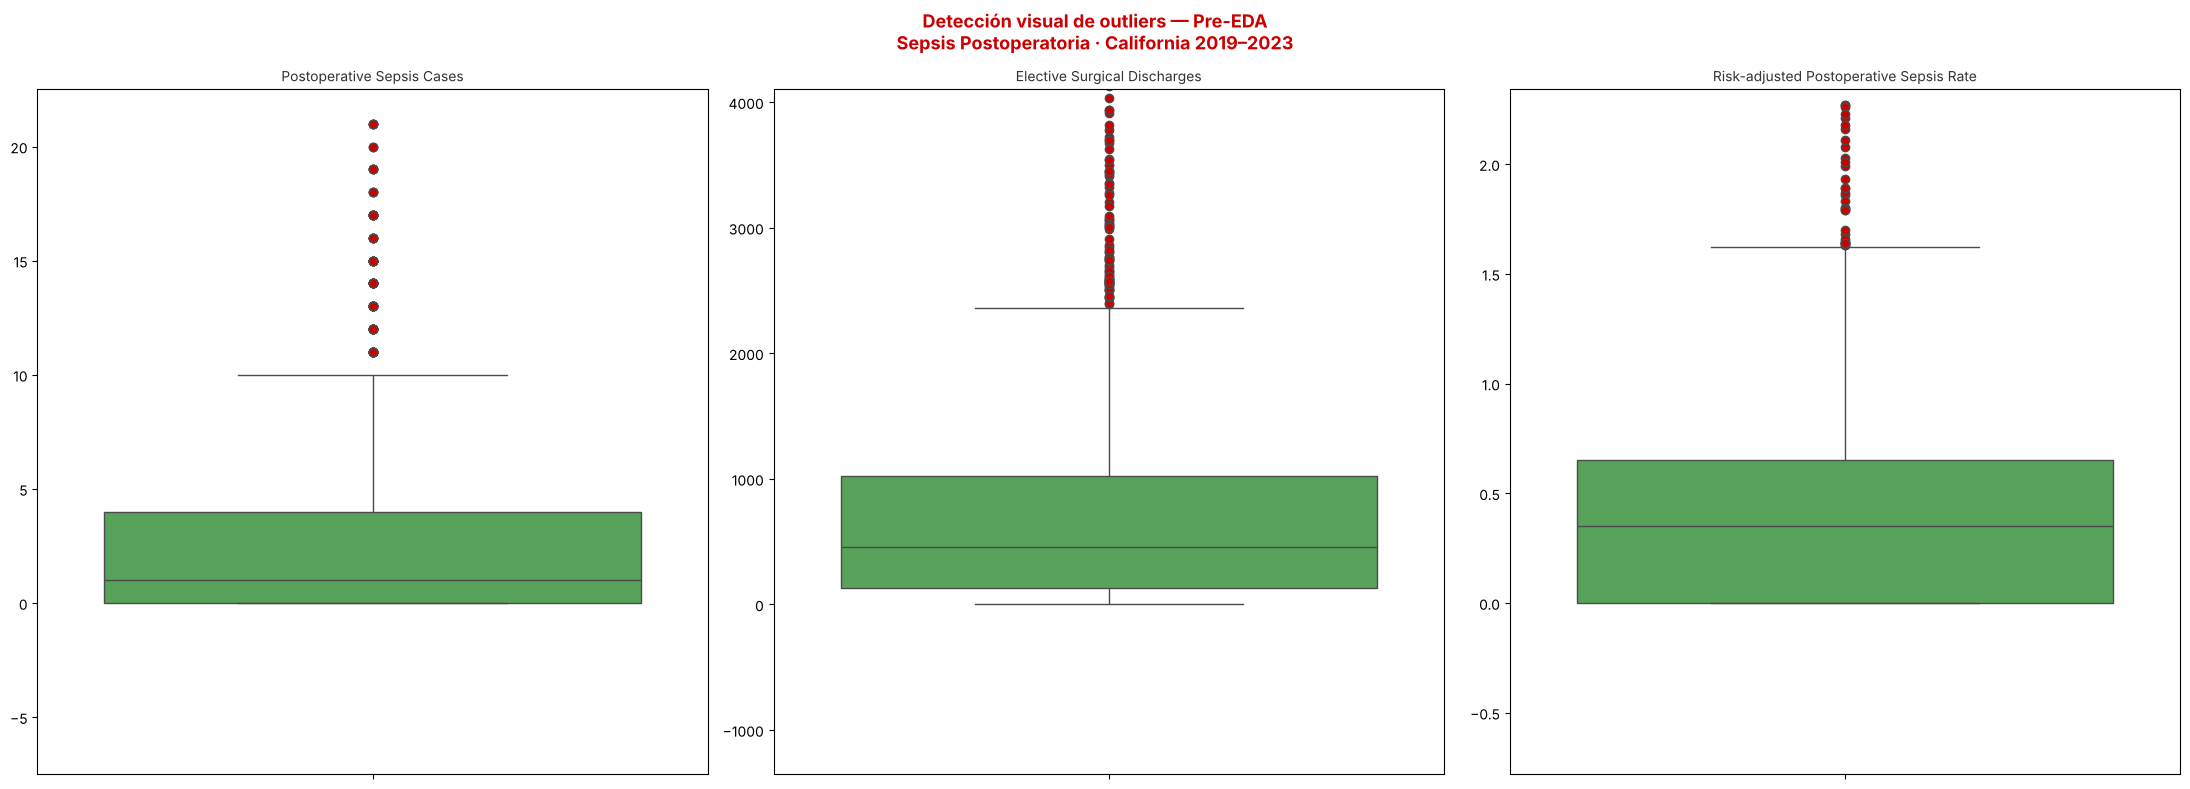

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

fig.suptitle(
    "Detección visual de outliers — Pre-EDA\nSepsis Postoperatoria · California 2019–2023",
    fontsize=13, fontweight="bold", color="#CC0000"
)

variables = [
    "Postoperative Sepsis Cases",
    "Elective Surgical Discharges",
    "Risk-adjusted Postoperative Sepsis Rate"
]

for ax, col in zip(axes, variables):
    sns.boxplot(
        y=df[col],
        ax=ax,
        color="#4CAF50",
        flierprops=dict(
            marker="o",
            markerfacecolor="#CC0000",
            markersize=6,
            linestyle="none"
        )
    )
    ax.set_title(col, fontsize=10, color="#333333")
    ax.set_ylabel("")

    # Escala independiente por variable
    q1 = df[col].quantile(0.05)
    q3 = df[col].quantile(0.95)
    margen = (q3 - q1) * 0.5
    ax.set_ylim(q1 - margen, q3 + margen)

plt.tight_layout()
plt.show()

## Visualización de la distribución central sin outliers

Se decide graficar un segundo boxplot excluyendo los outliers
de la visualización con el parámetro showfliers=False.

Esto no elimina los valores extremos del dataset —
siguen existiendo y serán evaluados en el análisis posterior.
El objetivo es ver con claridad la distribución de la mayor parte
de los hospitales de la froma mas clara posible


Boxplot con outliers visibles  →  muestra la realidad completa del dataset
Boxplot sin outliers            →  permite ver la distribución central con claridad


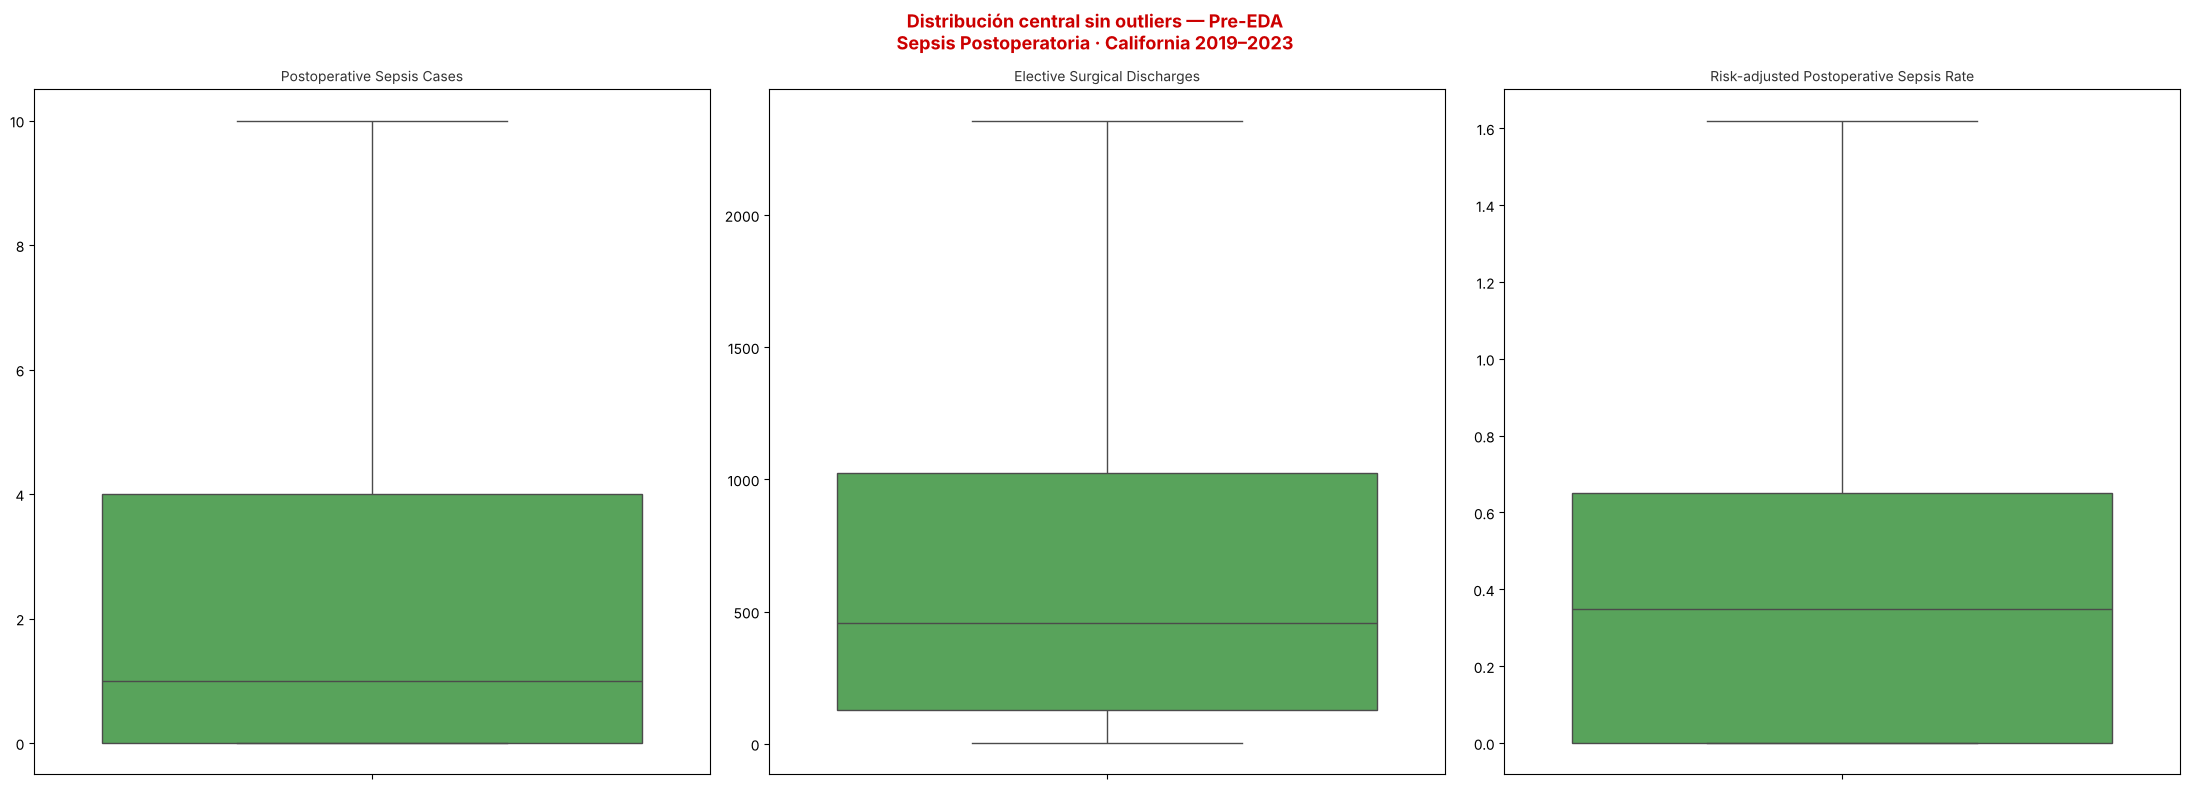

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

fig.suptitle(
    "Distribución central sin outliers — Pre-EDA\nSepsis Postoperatoria · California 2019–2023",
    fontsize=13, fontweight="bold", color="#CC0000"
)

variables = [
    "Postoperative Sepsis Cases",
    "Elective Surgical Discharges",
    "Risk-adjusted Postoperative Sepsis Rate"
]

for ax, col in zip(axes, variables):
    sns.boxplot(
        y=df[col],
        ax=ax,
        color="#4CAF50",
        showfliers=False
    )
    ax.set_title(col, fontsize=10, color="#333333")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [14]:
# IQR — límites formales de outliers
# Tres variables principales del análisis

variables = [
    'Postoperative Sepsis Cases',
    'Elective Surgical Discharges',
    'Risk-adjusted Postoperative Sepsis Rate'
]

for col in variables:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    print(f"\n{col}")
    print(f"  Q1: {Q1:.2f}  |  Q3: {Q3:.2f}  |  IQR: {IQR:.2f}")
    print(f"  Límite inferior: {lower:.2f}")
    print(f"  Límite superior: {upper:.2f}")
    print(f"  Hospitales fuera de rango: {outliers}")


Postoperative Sepsis Cases
  Q1: 0.00  |  Q3: 4.00  |  IQR: 4.00
  Límite inferior: -6.00
  Límite superior: 10.00
  Hospitales fuera de rango: 138

Elective Surgical Discharges
  Q1: 128.00  |  Q3: 1024.75  |  IQR: 896.75
  Límite inferior: -1217.12
  Límite superior: 2369.88
  Hospitales fuera de rango: 106

Risk-adjusted Postoperative Sepsis Rate
  Q1: 0.00  |  Q3: 0.65  |  IQR: 0.65
  Límite inferior: -0.98
  Límite superior: 1.62
  Hospitales fuera de rango: 64


## Primer hallazgo — concentración del evento

El primer gráfico muestra un patron significativo.

La caja de Postoperative Sepsis Cases tiene la mediana
en el cuarto inferior — eso significa que el 50% de los hospitales
tiene pocos casos de sepsis postoperatoria, valores bajos y parecidos
entre sí. Pero la distribución se estira hacia arriba,
lo que muestra una pequeño porcentaje de centros
con una cantidad de casos mucho más alta que el resto.

Epidemiológicamente esto es importante: hay pocos hospitales
que concentran la mayoría de los casos de infección postoperatoria.
Eso no es ruido — es una señal que marca exactamente
dónde hay que apuntar el análisis.


## Segundo hallazgo — qué muestra la tasa ajustada

Cuando se mira el tercer gráfico, la tasa ajustada por riesgo
muestra una distribución relativamente centrada.

Esa forma es compatible con el propósito del ajuste por riesgo: comparar
hospitales que atienden pacientes y contextos diferentes sin limitarse
a contar eventos absolutos. Sin embargo, **la forma del boxplot por sí sola
no demuestra que el ajuste sea perfecto ni que elimine todas las diferencias
entre instituciones**.

Una manera de entenderlo es que no resulta equivalente comparar los casos
brutos de un hospital con pacientes de mayor complejidad con los de otro
de menor complejidad. La tasa ajustada intenta corregir parte de esas
diferencias de case-mix para hacer la comparación más justa.

Por eso, en las etapas siguientes el indicador no se da por validado de
antemano: se estudia su relación con volumen, tiempo y persistencia.


## Segundo gráfico — Elective Surgical Discharges

La mediana en el tercio inferior dice que más de la mitad
de los hospitales de California opera poco volumen programado.

Esto muestra una gran concentración de la cirugía programada —
que suele ser la de mayor complejidad — en centros muy específicos.

Sin embargo, tomando encuenta
 el contexto de la pandemia COVID-19, esta mediana
también puede estar siendo empujada hacia abajo
por los años de suspensión quirúrgica progamada , no urgente.

Para tener un mejor perfil de esta variable
se analizará su evolución año por año en el análisis posterior.


## Análisis temporal — impacto de la pandemia sobre el denominador

Las hipótesis planteadas al inicio del análisis proponen que
la pandemia alteró tanto el volumen quirúrgico electivo como
el perfil de los pacientes operados en 2020-2021.
Esta sección evalúa esas hipótesis directamente sobre los datos.


In [15]:
# Filtrar filas institucionales — excluir STATEWIDE ya eliminado
df_hospitales = df[df['County'] != 'STATEWIDE'].copy()

# Evolución del volumen quirúrgico electivo por año
volumen_anual = df_hospitales.groupby('Year')['Elective Surgical Discharges'].sum()

# Evolución de la tasa ajustada promedio por año
tasa_anual = df_hospitales.groupby('Year')['Risk-adjusted Postoperative Sepsis Rate'].mean()

print("Volumen quirúrgico electivo total por año:")
print(volumen_anual)
print("\nTasa ajustada promedio por año:")
print(tasa_anual)

Volumen quirúrgico electivo total por año:
Year
2019    299021
2020    226507
2021    219060
2022    217034
2023    217916
Name: Elective Surgical Discharges, dtype: int64

Tasa ajustada promedio por año:
Year
2019    0.476192
2020    0.463163
2021    0.496305
2022    0.490034
2023    0.595819
Name: Risk-adjusted Postoperative Sepsis Rate, dtype: float64


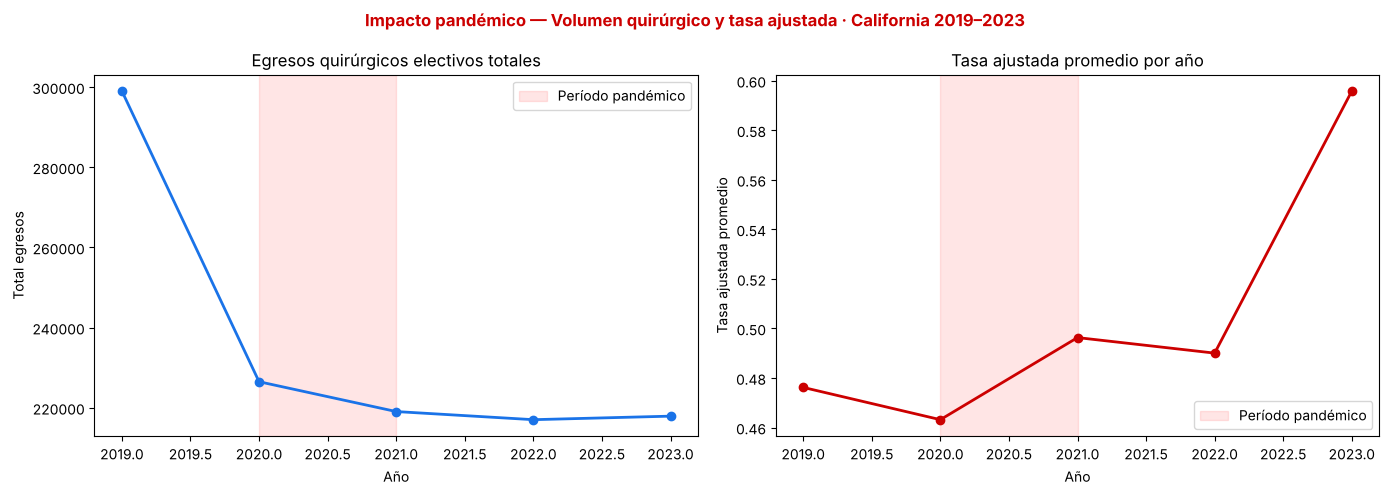

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    "Impacto pandémico — Volumen quirúrgico y tasa ajustada · California 2019–2023",
    fontsize=12, fontweight="bold", color="#CC0000"
)

ax1.plot(volumen_anual.index, volumen_anual.values,
         marker='o', color='#1a73e8', linewidth=2)
ax1.set_title("Egresos quirúrgicos electivos totales")
ax1.set_xlabel("Año")
ax1.set_ylabel("Total egresos")
ax1.axvspan(2020, 2021, alpha=0.1, color='red', label='Período pandémico')
ax1.legend()

ax2.plot(tasa_anual.index, tasa_anual.values,
         marker='o', color='#CC0000', linewidth=2)
ax2.set_title("Tasa ajustada promedio por año")
ax2.set_xlabel("Año")
ax2.set_ylabel("Tasa ajustada promedio")
ax2.axvspan(2020, 2021, alpha=0.1, color='red', label='Período pandémico')
ax2.legend()

plt.tight_layout()
plt.show()

## Análisis temporal — evolución del volumen quirúrgico 2019–2023

La celda anterior dejó abierta una pregunta:
¿cuánto afectó la pandemia al volumen de cirugías programadas
y qué impacto tuvo eso sobre el indicador central del análisis?

Dos hipótesis guiaron esta etapa desde el inicio:

**Hipótesis 1:** las cirugías programadas cayeron en 2020
por la suspensión masiva de procedimientos no urgentes
durante la pandemia COVID-19.

**Hipótesis 2:** la tasa ajustada de sepsis subió en ese período
porque el denominador bajó y el perfil de los pacientes
que sí fueron operados era de mayor gravedad y complejidad.

Los datos confirman la primera hipótesis
y matizan la segunda.

El volumen cayó un 24.4% entre 2019 y 2020
y no recuperó los niveles prepandémicos en ningún año posterior.
Sin embargo la tasa ajustada se mantuvo estable en ese mismo período —
lo que sugiere que el indicador absorbió el cambio de perfil
sin distorsión significativa.

La relación entre volumen, casos y tasa ajustada
se mantuvo proporcional durante 2020–2021.
El análisis institucional posterior es válido
para todo el período 2019–2023.


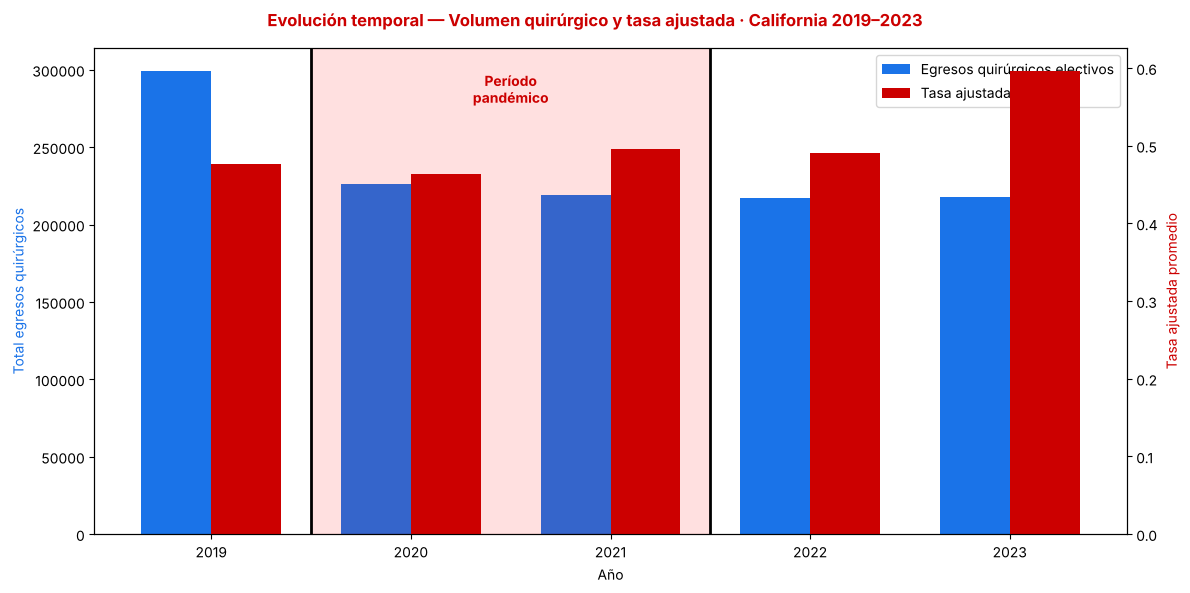

In [17]:
# Evolución temporal — volumen y tasa ajustada 2019-2023
volumen_anual = df_hospitales.groupby('Year')['Elective Surgical Discharges'].sum()
tasa_anual = df_hospitales.groupby('Year')['Risk-adjusted Postoperative Sepsis Rate'].mean()

años = volumen_anual.index.astype(str)
x = np.arange(len(años))
ancho = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))

fig.suptitle(
    "Evolución temporal — Volumen quirúrgico y tasa ajustada · California 2019–2023",
    fontsize=12, fontweight="bold", color="#CC0000"
)

# Barras volumen — eje izquierdo
barras1 = ax1.bar(x - ancho/2, volumen_anual.values,
                   ancho, label='Egresos quirúrgicos electivos',
                   color='#1a73e8')
ax1.set_xlabel("Año")
ax1.set_ylabel("Total egresos quirúrgicos", color='#1a73e8')
ax1.set_xticks(x)
ax1.set_xticklabels(años)

# Barras tasa ajustada — eje derecho
ax2 = ax1.twinx()
barras2 = ax2.bar(x + ancho/2, tasa_anual.values,
                   ancho, label='Tasa ajustada promedio',
                   color='#CC0000')
ax2.set_ylabel("Tasa ajustada promedio", color='#CC0000')

# Zona pandémica — fondo rojo con bordes negros bien definidos
ax1.axvspan(0.5, 2.5, alpha=0.12, color='red')
ax1.axvline(x=0.5, color='black', linewidth=2, linestyle='-')
ax1.axvline(x=2.5, color='black', linewidth=2, linestyle='-')

# Etiqueta del período pandémico
ax1.text(1.5, ax1.get_ylim()[1] * 0.95 if ax1.get_ylim()[1] > 0 else 250000,
         'Período\npandémico',
         ha='center', va='top',
         fontsize=10, fontweight='bold', color='#CC0000')

# Leyenda combinada
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper right')

plt.tight_layout()
plt.show()

## Etapa 5 — Correlaciones

Pocos hospitales concentran
la mayoría de los casos de sepsis postoperatoria.
Pero la pregunta es: ¿por qué?

La respuesta más obvia es volumen — el que más opera,
más casos tiene.
Por eso lo interesante no es correlacionar
casos con volumen sino ver qué pasa con la tasa ajustada.
Si realmente ajusta por riesgo, tendría que ser independiente
del tamaño del hospital.


## Análisis por grupo — antes de correlacionar

Los boxplots mostraron que hay dispersión importante en todas
las variables principales, por lo que decido agrupar a los hospitales
para observar cómo se comportan casos, volumen y tasa dentro de las
categorías oficiales de desempeño.

La variable elegida es Performance Rating —la calificación oficial
que clasifica a cada hospital como Above Average, Average o Below Average—.
**Importante:** esta clasificación está vinculada al desempeño medido por
la tasa ajustada, por lo que el análisis por grupos es descriptivo y no
constituye una validación independiente del indicador.


## Correlaciones — hipótesis previa

Para la primera correlación espero un resultado alto:
a mayor volumen de cirugías, más casos absolutos de sepsis.
Más pacientes, más exposición. Tiene una secuencia lógica, y esperable.

Para la segunda espero un resultado bajo o cercano a cero:
si la tasa ajustada funciona correctamente debería ser
independiente del tamaño del hospital.


In [18]:
groupby_crudo = df.groupby(
    'Risk-adjustedAveragePerformanceAverageRating')[
    ['Postoperative Sepsis Cases',
     'Elective Surgical Discharges']].mean().round(2)

print(groupby_crudo)

                                              Postoperative Sepsis Cases  \
Risk-adjustedAveragePerformanceAverageRating                               
Above Average                                                       5.51   
Average                                                             3.19   
Below Average                                                      16.48   

                                              Elective Surgical Discharges  
Risk-adjustedAveragePerformanceAverageRating                                
Above Average                                                      2275.00  
Average                                                             717.73  
Below Average                                                      1602.48  


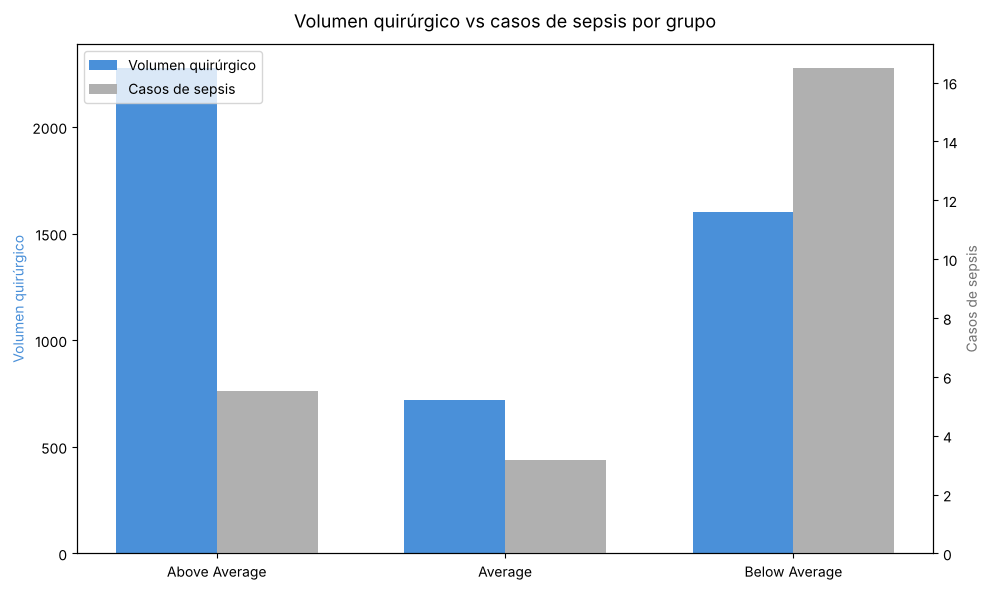

In [19]:
import numpy as np

fig, ax1 = plt.subplots(figsize=(10, 6))

grupos = ['Above Average', 'Average', 'Below Average']
volumen = [2275.00, 717.73, 1602.48]
casos = [5.51, 3.19, 16.48]

x = np.arange(len(grupos))
ancho = 0.35

ax2 = ax1.twinx()

ax1.bar(x - ancho/2, volumen, ancho,
        label='Volumen quirúrgico',
        color='#4A90D9', edgecolor='none')

ax2.bar(x + ancho/2, casos, ancho,
        label='Casos de sepsis',
        color='#B0B0B0', edgecolor='none')

ax1.set_xticks(x)
ax1.set_xticklabels(grupos)
ax1.set_ylabel('Volumen quirúrgico', color='#4A90D9')
ax2.set_ylabel('Casos de sepsis', color='#707070')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Volumen quirúrgico vs casos de sepsis por grupo',
          fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## Hallazgo descriptivo — volumen vs casos por grupo

Al dividir los hospitales por calificación aparece un contraste interesante.

Above Average opera más —2275 cirugías promedio—
y tiene menos casos de sepsis —5.51.
Below Average opera menos —1602 cirugías—
y presenta más casos —16.48.

Este contraste merece profundización, pero debe interpretarse con cautela:
Performance Rating no es una variable externa al sistema de evaluación,
por lo que estas diferencias describen los grupos oficiales y no prueban,
por sí solas, que el volumen o la calidad causen el resultado.

Se procederá a analizar la tasa ajustada y luego las relaciones entre
volumen y tasa para profundizar este resultado inicial.


In [20]:
groupby_ajustado = df.groupby(
    'Risk-adjustedAveragePerformanceAverageRating')[
    ['Postoperative Sepsis Cases',
     'Elective Surgical Discharges',
     'Risk-adjusted Postoperative Sepsis Rate']].mean().round(2)

print(groupby_ajustado)

                                              Postoperative Sepsis Cases  \
Risk-adjustedAveragePerformanceAverageRating                               
Above Average                                                       5.51   
Average                                                             3.19   
Below Average                                                      16.48   

                                              Elective Surgical Discharges  \
Risk-adjustedAveragePerformanceAverageRating                                 
Above Average                                                      2275.00   
Average                                                             717.73   
Below Average                                                      1602.48   

                                              Risk-adjusted Postoperative Sepsis Rate  
Risk-adjustedAveragePerformanceAverageRating                                           
Above Average                                       

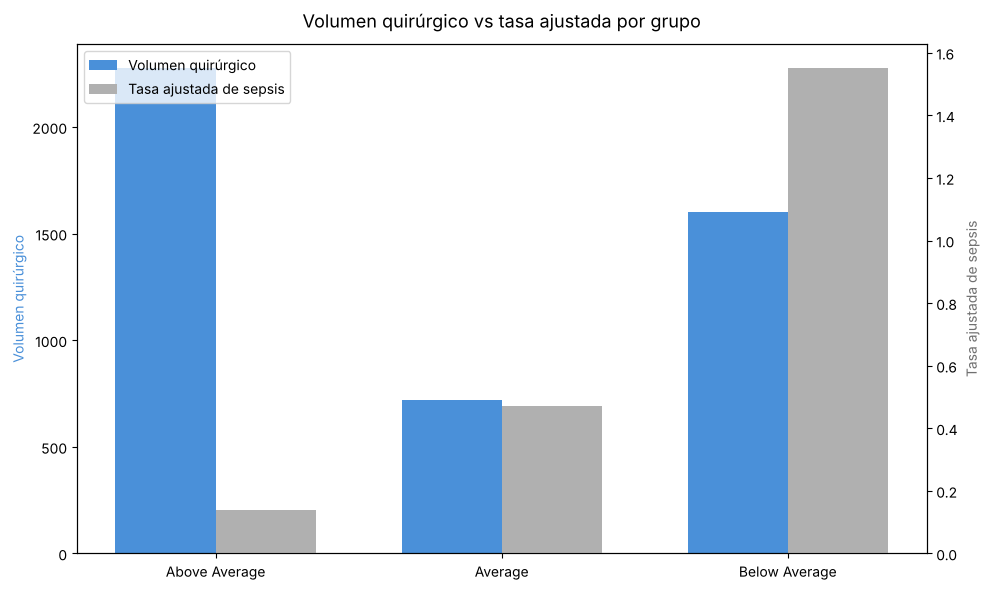

In [21]:
fig, ax1 = plt.subplots(figsize=(10, 6))

grupos = ['Above Average', 'Average', 'Below Average']
volumen = [2275.00, 717.73, 1602.48]
tasa = [0.14, 0.47, 1.55]

x = np.arange(len(grupos))
ancho = 0.35

ax2 = ax1.twinx()

ax1.bar(x - ancho/2, volumen, ancho,
        label='Volumen quirúrgico',
        color='#4A90D9', edgecolor='none')

ax2.bar(x + ancho/2, tasa, ancho,
        label='Tasa ajustada de sepsis',
        color='#B0B0B0', edgecolor='none')

ax1.set_xticks(x)
ax1.set_xticklabels(grupos)
ax1.set_ylabel('Volumen quirúrgico', color='#4A90D9')
ax2.set_ylabel('Tasa ajustada de sepsis', color='#707070')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Volumen quirúrgico vs tasa ajustada por grupo',
          fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## Rosa de Nightingale — visualización histórica

Florence Nightingale (1820–1910) desarrolló este tipo de gráfico
para comunicar causas de mortalidad hospitalaria a tomadores
de decisiones que no leían tablas estadísticas.
Al ser este un análisis sobre un tema sanitario y epidemiologico, pienso es pertinente la referencia , siendo aun hoy un modelo de visualizacion d euna claridad una claridad sorprendente .


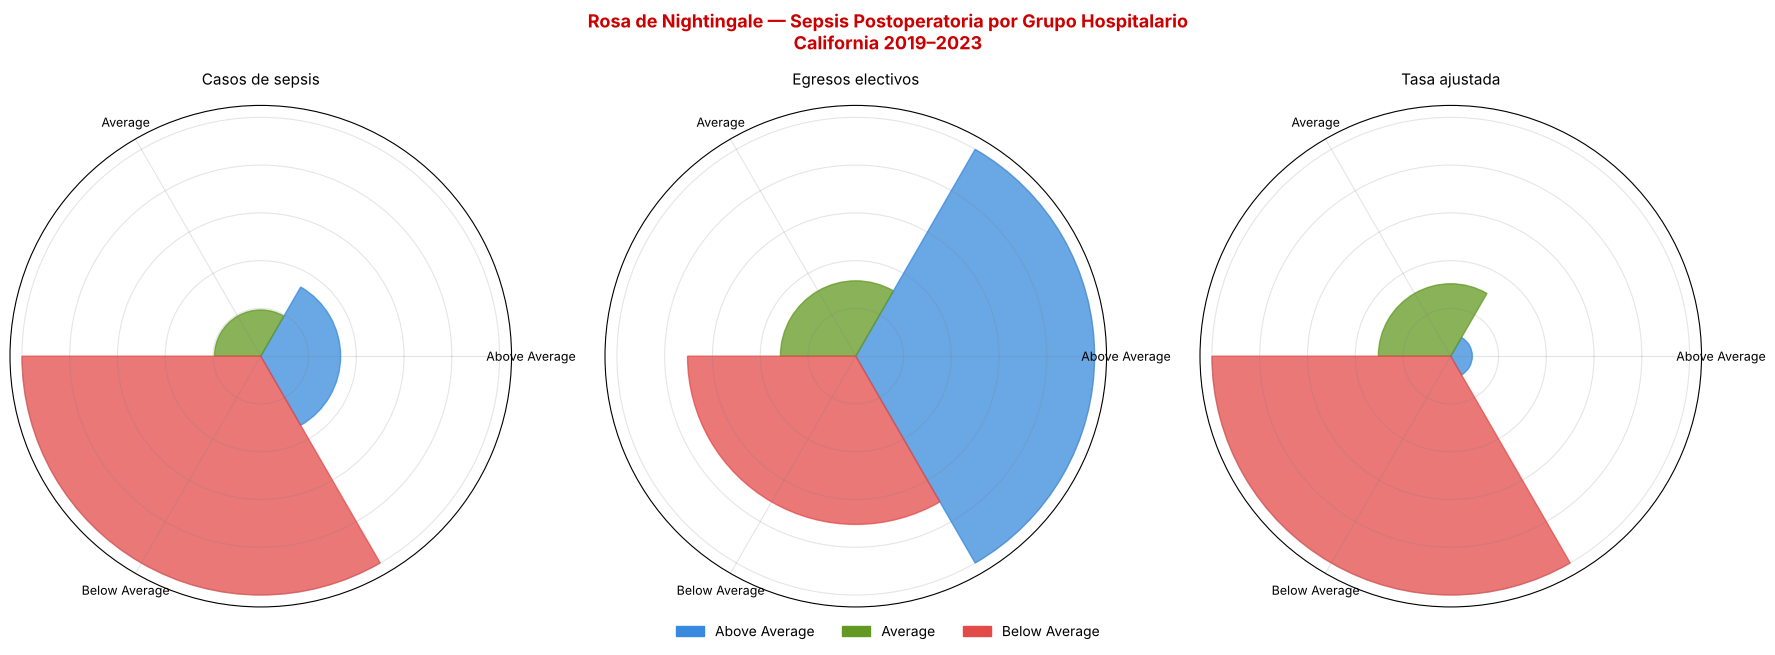

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

grupos = ['Above Average', 'Average', 'Below Average']
casos = [5.51, 3.19, 16.48]
volumen = [2275.00, 717.73, 1602.48]
tasa = [0.14, 0.47, 1.55]

variables = [
    ('Casos de sepsis', casos),
    ('Egresos electivos', volumen),
    ('Tasa ajustada', tasa)
]

colores = ['#378ADD', '#639922', '#E24B4A']
n = len(grupos)
angulos = np.linspace(0, 2 * np.pi, n, endpoint=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          subplot_kw=dict(polar=True))

fig.suptitle(
    'Rosa de Nightingale — Sepsis Postoperatoria por Grupo Hospitalario\n'
    'California 2019–2023',
    fontsize=13, fontweight='bold', color='#CC0000', y=1.02
)

for ax, (titulo, valores) in zip(axes, variables):
    max_val = max(valores)
    radios = [v / max_val for v in valores]

    for i, (radio, color, grupo) in enumerate(
            zip(radios, colores, grupos)):
        theta = angulos[i]
        ax.bar(theta, radio,
               width=2 * np.pi / n,
               color=color, alpha=0.75,
               edgecolor=color, linewidth=1)

    ax.set_xticks(angulos)
    ax.set_xticklabels(grupos, fontsize=9)
    ax.set_yticklabels([])
    ax.set_title(titulo, fontsize=11, pad=15)
    ax.grid(color='gray', alpha=0.2)

patches = [mpatches.Patch(color=c, label=g)
           for c, g in zip(colores, grupos)]
fig.legend(handles=patches, loc='lower center',
           ncol=3, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

## Confirmación descriptiva — tasa ajustada

La tasa ajustada descuenta factores del perfil de riesgo incluidos en el
modelo utilizado por el sistema. El patrón descriptivo entre categorías
se mantiene: Above Average 0.14 y Below Average 1.55.

La diferencia es marcada, pero no debe tomarse como una validación
independiente: Performance Rating está relacionado con el propio indicador
de desempeño. Su utilidad en esta etapa es mostrar cómo se distribuye la
tasa dentro de las categorías oficiales y orientar las preguntas del
análisis posterior.


## Por qué  uso Spearman y no Pearson

Los boxplots de la etapa anterior mostraron outliers
importantes en Sepsis Cases y en Elective Discharges.
Eso descarta Pearson,que es muy sensible a outliers

Spearman trabaja con rangos, no con valores absolutos,
así que los outliers no lo distorsionan. Además la relación
que estamos buscando es una relacion que no es obligatoriamente lineal — cuando el volumen sube,
los casos tienden a subir —
Por eso Spearman es el método que corresponde acá.


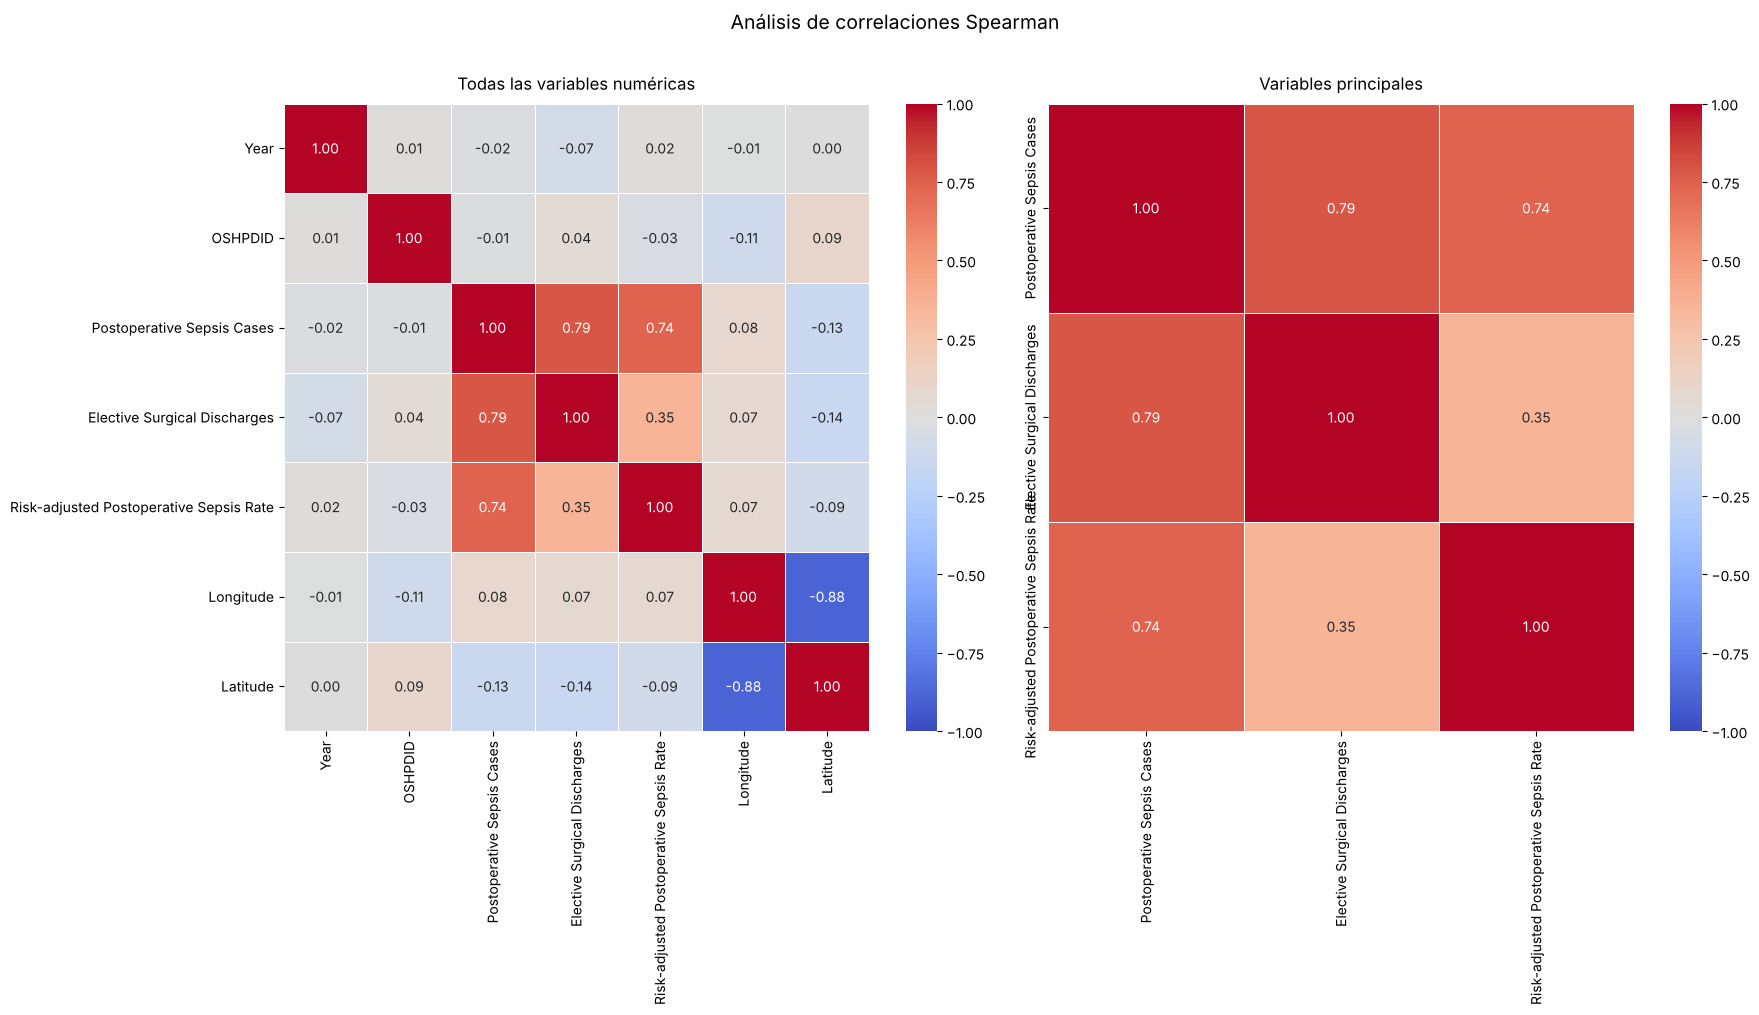

In [23]:
fig = plt.figure(figsize=(18, 10))

# Heatmap 1 — todas las variables
ax1 = fig.add_subplot(1, 2, 1)
corr_completo = df.corr(method='spearman', numeric_only=True)
sns.heatmap(corr_completo, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5,
            vmin=-1, vmax=1, ax=ax1)
ax1.set_title('Todas las variables numéricas', fontsize=12, pad=10)

# Heatmap 2 — tres variables principales
ax2 = fig.add_subplot(1, 2, 2)
corr_tres = df[['Postoperative Sepsis Cases',
                'Elective Surgical Discharges',
                'Risk-adjusted Postoperative Sepsis Rate']]\
              .corr(method='spearman')
sns.heatmap(corr_tres, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5,
            vmin=-1, vmax=1, ax=ax2)
ax2.set_title('Variables principales', fontsize=12, pad=10)

plt.suptitle('Análisis de correlaciones Spearman',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Correlación Spearman — coeficiente y significancia estadística

El heatmap muestra la correlación visualmente.
Acá se imprime el número exacto con su p-value
para confirmar que la relación no es producto del azar.


In [24]:
from scipy import stats

pares = [
    ('Elective Surgical Discharges', 'Postoperative Sepsis Cases'),
    ('Elective Surgical Discharges', 'Risk-adjusted Postoperative Sepsis Rate'),
    ('Postoperative Sepsis Cases', 'Risk-adjusted Postoperative Sepsis Rate')
]

for var1, var2 in pares:
    corr, p = stats.spearmanr(df[var1], df[var2])
    significancia = "significativa" if p < 0.05 else "no significativa"
    print(f"\n{var1} vs {var2}")
    print(f"  ρ = {corr:.3f}  |  p-value = {p:.4f}  |  {significancia}")


Elective Surgical Discharges vs Postoperative Sepsis Cases
  ρ = 0.787  |  p-value = 0.0000  |  significativa

Elective Surgical Discharges vs Risk-adjusted Postoperative Sepsis Rate
  ρ = 0.355  |  p-value = 0.0000  |  significativa

Postoperative Sepsis Cases vs Risk-adjusted Postoperative Sepsis Rate
  ρ = 0.736  |  p-value = 0.0000  |  significativa


### Matrices de correlación Spearman

A la izquierda todas las variables numéricas del dataset.
A la derecha el foco en las tres variables centrales del análisis.
El ρ=0.35 entre volumen y tasa ajustada es el hallazgo que desebcadena el resto del análisis.


## Análisis de los resultados

La primera mirada a los datos crudos era esperable:
ρ=0.79 confirma una asociación fuerte entre volumen y casos absolutos.
Más pacientes operados, más exposición.

Al separar por Performance Rating aparecen datos contrastantes:
Above Average opera más —2275 cirugías— y presenta menos casos que
Below Average —1602 cirugías y 16.48 casos promedio—. Este resultado es
descriptivo: la categoría de desempeño forma parte del mismo sistema de
evaluación y no funciona como una validación externa.

Luego, al estudiar volumen y tasa ajustada, aparece una asociación de
Spearman de ρ=0.355. Esto indica una relación monotónica moderada en las
observaciones hospital-año, pero no demuestra todavía que el volumen
explique la tasa ni que el indicador falle.

¿Qué hospitales sostienen un desempeño desfavorable en el tiempo?
¿Dónde se encuentran? ¿Qué parte del patrón puede relacionarse con volumen,
persistencia o características no disponibles en el dataset? Esas preguntas
guían la profundización del análisis.


## Índice de persistencia — construcción de la variable central

El dataset registra un valor por hospital por año.
Un hospital puede ser Below Average un año por razones puntuales
— pandemia, cambio de gestión, un evento aislado —
y recuperarse al siguiente.

Para distinguir un problema puntual de uno estructural
se construye el índice de persistencia:
la cantidad de años que cada hospital permaneció
en cada nivel de desempeño durante el período 2019–2023.

Un hospital con 1 o 2 años Below Average es ocasional.
Un hospital con 3 o más años es crónico —
su problema no se resolvió con el tiempo.

**Esta variable no estaba en el dataset original**.
Se establece esta variable para poder simplificar en un solo análisis y visualizacion todos los componentes del análisis: epidemiologicos-temporales-geograficos, generando una accesibilidad y claridad conceptuales optimas.


In [25]:
# ── Índice de persistencia ──────────────────────────────────────────
# Cuenta cuántos años cada hospital fue clasificado como Below/Above Average
# Fuente: variable Risk-adjustedAveragePerformanceAverageRating

df['is_below'] = df['Risk-adjustedAveragePerformanceAverageRating']\
    .str.contains('Below', na=False).astype(int)

df['is_above'] = df['Risk-adjustedAveragePerformanceAverageRating']\
    .str.contains('Above', na=False).astype(int)

persistencia = df.groupby('OSHPDID').agg(
    nombre      = ('Hospital Name', 'first'),
    lat         = ('Latitude', 'mean'),
    lon         = ('Longitude', 'mean'),
    below_years = ('is_below', 'sum'),
    above_years = ('is_above', 'sum')
).reset_index()

def grupo(row):
    if row['below_years'] >= 3:   return 'cronico_below'
    elif row['below_years'] >= 1: return 'ocasional_below'
    elif row['above_years'] >= 3: return 'cronico_above'
    else:                         return 'average'

persistencia['grupo'] = persistencia.apply(grupo, axis=1)

# ── Volumen quirúrgico real ─────────────────────────────────────────
volumen_real = (
    df.groupby('OSHPDID')['Elective Surgical Discharges']
    .mean()
    .reset_index()
    .rename(columns={'Elective Surgical Discharges': 'volumen'})
)
persistencia = persistencia.merge(volumen_real, on='OSHPDID', how='left')

# ── Tasa ajustada promedio ──────────────────────────────────────────
tasa_promedio = (
    df.groupby('OSHPDID')['Risk-adjusted Postoperative Sepsis Rate']
    .mean()
    .reset_index()
    .rename(columns={'Risk-adjusted Postoperative Sepsis Rate': 'tasa'})
)
persistencia = persistencia.merge(tasa_promedio, on='OSHPDID', how='left')


# ── Casos acumulados de sepsis por hospital ─────────────────────────
# Se agrega por separado del volumen quirúrgico para no confundir
# egresos electivos con casos de sepsis.
sepsis_total = (
    df.groupby('OSHPDID')['Postoperative Sepsis Cases']
    .sum()
    .reset_index()
    .rename(columns={'Postoperative Sepsis Cases': 'sepsis_total'})
)
persistencia = persistencia.merge(sepsis_total, on='OSHPDID', how='left')

print(persistencia['grupo'].value_counts())
print(f"\nTotal hospitales: {len(persistencia)}")
print(f"Columnas: {persistencia.columns.tolist()}")


grupo
average            264
ocasional_below     40
cronico_below        5
cronico_above        3
Name: count, dtype: int64

Total hospitales: 312
Columnas: ['OSHPDID', 'nombre', 'lat', 'lon', 'below_years', 'above_years', 'grupo', 'volumen', 'tasa', 'sepsis_total']


In [26]:
print(persistencia.columns.tolist())

['OSHPDID', 'nombre', 'lat', 'lon', 'below_years', 'above_years', 'grupo', 'volumen', 'tasa', 'sepsis_total']


## Profundización del análisis — Integración de variables

El análisis hasta aquí trabajó las variables por separado:
volumen, tasa ajustada, desempeño por grupo
y distribución geográfica.

El paso siguiente integra todas estas dimensiones
en una única visualización, incorporando además
la variable temporal: posición geográfica,
nivel de desempeño, persistencia en el tiempo
y volumen de casos en un solo gráfico. Para facilitar el seguimiento del hilo narrativo, buscare graficar los resutados de el forma mas simple e integradora.


## Gráfico — Metodología aplicada

Busco integrar en un solo gráfico las variables epidemiológicas, geográficas y temporales de la forma más simple y clara, para una interpretación accesible.

Dos variables complejas se transforman en elementos clave del análisis: Tasa reajustada y Persistencia (la cantidad de tiempo que cada hospital permaneció en promedio, durante el período en estudio, en cada nivel de performance asociado a infecciones postoperatorias).


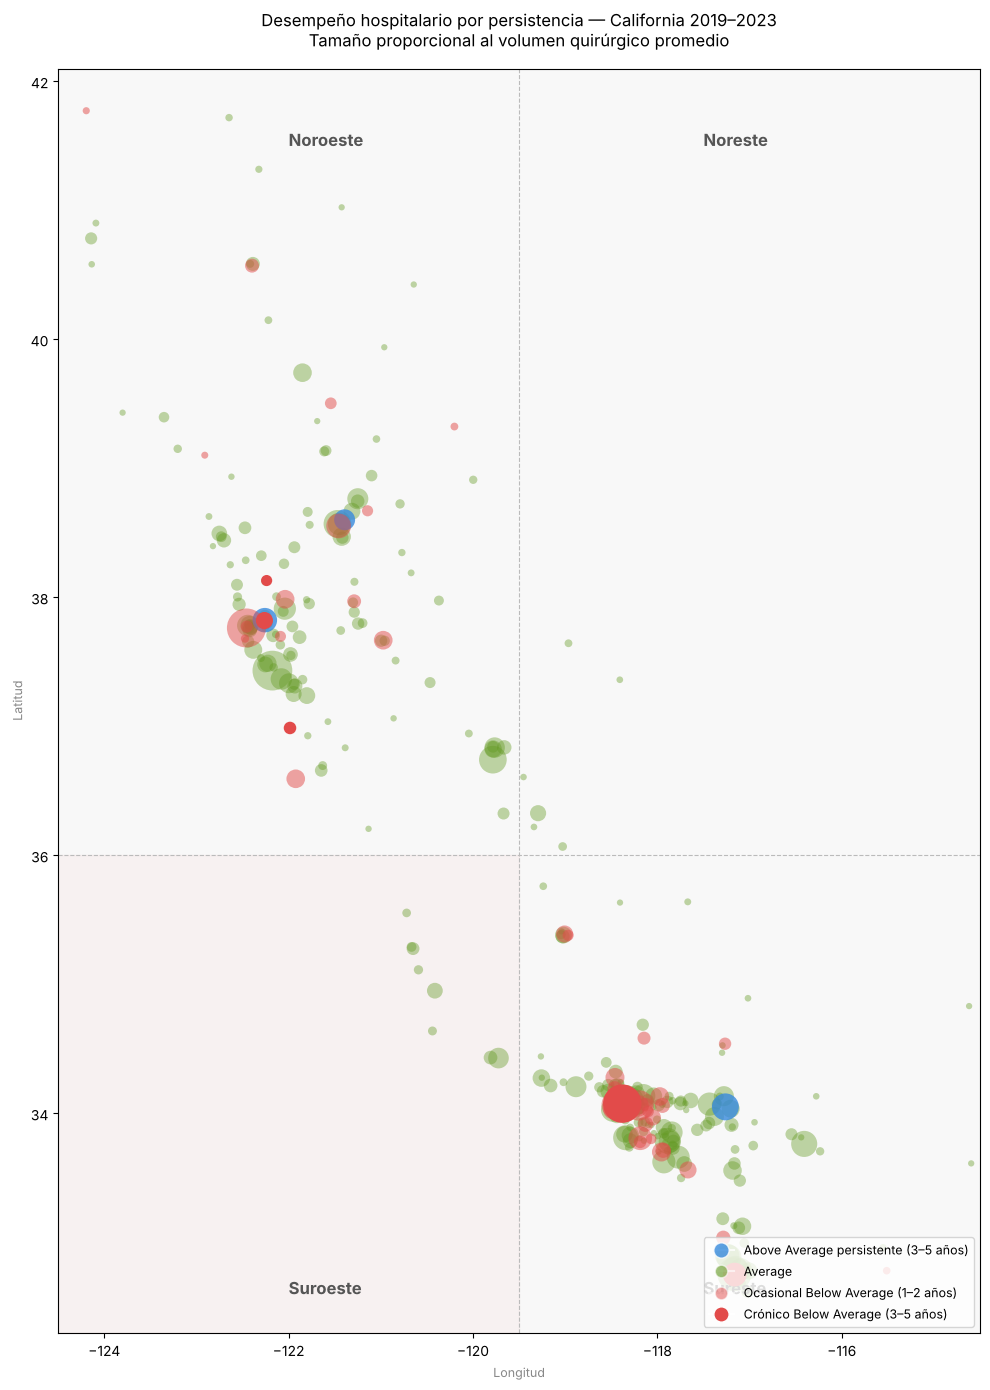

In [27]:
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ── Parámetros ──────────────────────────────────────────────────────
LON_MIN, LON_MAX = -124.5, -114.5
LAT_MIN, LAT_MAX =   32.3,   42.1
LON_MED, LAT_MED = -119.5,   36.0
MAX_CASOS = persistencia['tasa'].max()

COLORES = {
    'cronico_above':   '#378ADD',
    'average':         '#639922',
    'ocasional_below': '#E24B4A',
    'cronico_below':   '#E24B4A',
}

ALPHAS = {
    'cronico_above':   0.8,
    'average':         0.4,
    'ocasional_below': 0.5,
    'cronico_below':   1.0,
}

# ── Gráfico ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 14))
ax.set_facecolor('#F8F8F8')
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)

ax.axvline(LON_MED, color='#BBBBBB', lw=0.8, ls='--')
ax.axhline(LAT_MED, color='#BBBBBB', lw=0.8, ls='--')

ax.add_patch(Rectangle(
    (LON_MIN, LAT_MIN),
    LON_MED - LON_MIN,
    LAT_MED - LAT_MIN,
    color='#E24B4A', alpha=0.04
))

ax.text(-122.0, 41.5, 'Noroeste', fontsize=12, color='#555555', fontweight='bold')
ax.text(-117.5, 41.5, 'Noreste',  fontsize=12, color='#555555', fontweight='bold')
ax.text(-122.0, 32.6, 'Suroeste', fontsize=12, color='#555555', fontweight='bold')
ax.text(-117.5, 32.6, 'Sureste',  fontsize=12, color='#555555', fontweight='bold')

orden = ['average', 'cronico_above', 'ocasional_below', 'cronico_below']
for g in orden:
    sub = persistencia[persistencia['grupo'] == g]
    sizes = (sub['volumen'] / persistencia['volumen'].max()) * 800 + 20
    ax.scatter(
        sub['lon'], sub['lat'],
        s=sizes,
        c=COLORES[g],
        alpha=ALPHAS[g],
        edgecolors='none',
        linewidths=0,
        zorder=orden.index(g) + 2
    )

leyenda = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#378ADD',
           markersize=11, alpha=0.8, label='Above Average persistente (3–5 años)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#639922',
           markersize=9,  alpha=0.6, label='Average'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A',
           markersize=9,  alpha=0.5, label='Ocasional Below Average (1–2 años)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A',
           markersize=11, alpha=1.0, label='Crónico Below Average (3–5 años)'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=9, framealpha=0.8)

ax.set_title(
    'Desempeño hospitalario por persistencia — California 2019–2023\n'
    'Tamaño proporcional al volumen quirúrgico promedio',
    fontsize=12, pad=16
)
ax.set_xlabel('Longitud', fontsize=9, color='#888888')
ax.set_ylabel('Latitud',  fontsize=9, color='#888888')

plt.tight_layout()
plt.show()

## Referencias del gráfico

**Período:** 2019–2023 · 312 hospitales · California

**Clasificación por persistencia en el período:**

- 🔵 **Azul** — Above Average 3 o más años
- 🟢 **Verde** — Average predominante
- 🔴 **Rojo claro** — Below Average 1–2 años (ocasional)
- 🔴 **Rojo intenso** — Below Average 3–5 años (crónico)

**Tamaño de burbuja** — volumen promedio de casos de sepsis postoperatoria

**División geográfica** — líneas punteadas por mediana de latitud y longitud del dataset
Sombreado rojo: cuadrante suroeste


## Distribución geográfica de hospitales Below Average

Del total de hospitales con al menos un año de desempeño
Below Average — es decir, con tasas de sepsis postoperatoria
superiores a lo esperado según el perfil de riesgo de sus pacientes —
en el período 2019–2023, el 40% se concentra en el suroeste
y el 40% en el noroeste, con un 20% restante en el sureste.
El cuadrante noreste no registra ningún hospital en esta categoría.

Los 5 hospitales con desempeño crónicamente Below Average
se distribuyen: 3 en el noroeste, 1 en el suroeste
y 1 en el sureste.

La siguiente pregunta es ...cuales hospitales tienen un peor desempeño a lo largo de este periodo, cuales tienen mayor peso en el balance total?


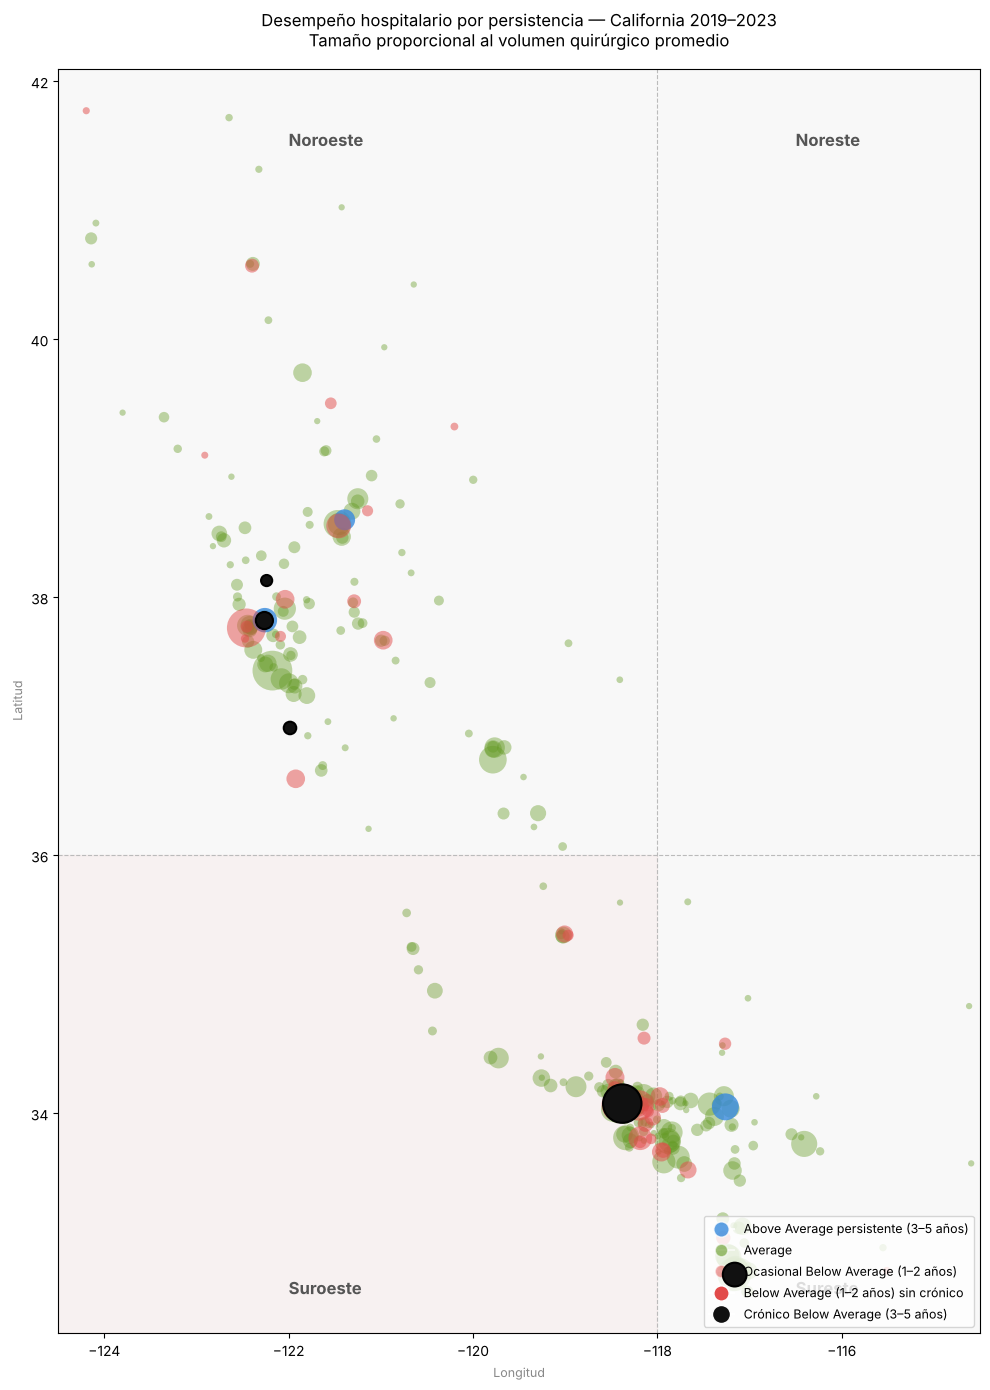

In [28]:
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ── Parámetros ──────────────────────────────────────────────────────
LON_MIN, LON_MAX = -124.5, -114.5
LAT_MIN, LAT_MAX =   32.3,   42.1
LON_MED, LAT_MED = -118.0,   36.0
MAX_CASOS = persistencia['volumen'].max()

COLORES = {
    'cronico_above':   '#378ADD',
    'average':         '#639922',
    'ocasional_below': '#E24B4A',
    'cronico_below':   '#E24B4A',
}

ALPHAS = {
    'cronico_above':   0.8,
    'average':         0.4,
    'ocasional_below': 0.5,
    'cronico_below':   1.0,
}

# ── Gráfico ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 14))
ax.set_facecolor('#F8F8F8')
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)

ax.axvline(LON_MED, color='#BBBBBB', lw=0.8, ls='--')
ax.axhline(LAT_MED, color='#BBBBBB', lw=0.8, ls='--')

ax.add_patch(Rectangle(
    (LON_MIN, LAT_MIN),
    LON_MED - LON_MIN,
    LAT_MED - LAT_MIN,
    color='#E24B4A', alpha=0.04
))

ax.text(-122.0, 41.5, 'Noroeste', fontsize=12, color='#555555', fontweight='bold')
ax.text(-116.5, 41.5, 'Noreste',  fontsize=12, color='#555555', fontweight='bold')
ax.text(-122.0, 32.6, 'Suroeste', fontsize=12, color='#555555', fontweight='bold')
ax.text(-116.5, 32.6, 'Sureste',  fontsize=12, color='#555555', fontweight='bold')

orden = ['average', 'cronico_above', 'ocasional_below', 'cronico_below']
for g in orden:
    sub = persistencia[persistencia['grupo'] == g]
    sizes = (sub['volumen'] / MAX_CASOS) * 800 + 20
    ax.scatter(
        sub['lon'], sub['lat'],
        s=sizes,
        c=COLORES[g],
        alpha=ALPHAS[g],
        edgecolors='none',
        linewidths=0,
        zorder=orden.index(g) + 2
    )

# ── 5 crónicos en negro encima ──────────────────────────────────────
cronicos = persistencia[persistencia['grupo'] == 'cronico_below']
sizes_cronicos = (cronicos['volumen'] / MAX_CASOS) * 800 + 20

ax.scatter(
    cronicos['lon'], cronicos['lat'],
    s=sizes_cronicos,
    c='#111111',
    alpha=1.0,
    edgecolors='#000000',
    linewidths=1.5,
    zorder=10
)

leyenda = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#378ADD',
           markersize=11, alpha=0.8, label='Above Average persistente (3–5 años)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#639922',
           markersize=9,  alpha=0.6, label='Average'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A',
           markersize=9,  alpha=0.5, label='Ocasional Below Average (1–2 años)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A',
           markersize=11, alpha=1.0, label='Below Average (1–2 años) sin crónico'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#111111',
           markersize=13, label='Crónico Below Average (3–5 años)'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=9, framealpha=0.8)

ax.set_title(
    'Desempeño hospitalario por persistencia — California 2019–2023\n'
    'Tamaño proporcional al volumen quirúrgico promedio',
    fontsize=12, pad=16
)
ax.set_xlabel('Longitud', fontsize=9, color='#888888')
ax.set_ylabel('Latitud',  fontsize=9, color='#888888')

plt.tight_layout()
plt.show()

*Nota: la línea de corte longitudinal fue ajustada
para reflejar con mayor precisión la geografía real
de California.**Nota: la línea de corte longitudinal fue ajustada
para reflejar con mayor precisión la geografía real
de California.*


## Evaluación de los 5 hospitales de mayor persistencia
## en el parámetro de peor desempeño — Below Average

El análisis de los 5 hospitales crónicos muestra
perfiles distintos entre sí.

Cedars-Sinai y Scripps Mercy aparecen en zonas densas
y con alto volumen quirúrgico. Alta Bates presenta un patrón similar
en una zona de densidad moderada.

Dominican y Sutter Solano son casos diferentes:
tienen menor volumen y, por lo tanto, un denominador potencialmente
más sensible a pequeñas variaciones en el número de eventos.

Cinco hospitales persistentes, perfiles diferentes y sin un único
parámetro común evidente en las variables disponibles.

La presencia de un hospital de gran volumen rodeado de múltiples hospitales
con episodios ocasionales en la misma zona geográfica define el foco
del siguiente paso del análisis.


## Zona de concentración crítica — foco del análisis

El gráfico muestra una concentración geográfica que merece ser explorada:
un hospital con desempeño persistentemente Below Average aparece rodeado
de múltiples hospitales con episodios ocasionales en la misma zona.

Esto identifica el área suroeste como una zona de interés para la siguiente
etapa del análisis. La concentración geográfica por sí sola no permite
atribuir causalidad ni complejidad clínica; funciona como señal para
profundizar la exploración.


## Hallazgo geográfico — límite de lo que puede inferirse

El análisis de concentración geográfica revela un patrón que merece
atención metodológica.

En un radio de 12 km alrededor de Cedars-Sinai se concentra una proporción
relevante de hospitales del área. La celda siguiente calcula, utilizando
**Postoperative Sepsis Cases**, qué proporción real de los casos acumulados
de sepsis del dataset corresponde a ese radio.

Entre los hospitales con episodios Below Average de esa zona aparecen
Cedars-Sinai, Ronald Reagan UCLA, Good Samaritan y Santa Monica UCLA.

Por conocimiento clínico es razonable plantear que algunos grandes centros
de referencia pueden concentrar casos complejos, pero **esa complejidad
específica no está medida en este dataset**. Por eso se considera una
hipótesis explicativa y no un resultado demostrado por estos datos.

La pregunta que surge sigue siendo relevante:

¿La tasa ajustada mantiene el mismo comportamiento en hospitales que se
encuentran en extremos de volumen y persistencia?

¿Cuáles son los límites operativos de un indicador cuyo denominador y
case-mix pueden variar ampliamente entre instituciones?


## Resultado del análisis de radio — Cedars-Sinai como foco exploratorio

La celda siguiente identifica los hospitales ubicados dentro de un radio
de 12 km alrededor de Cedars-Sinai y calcula dos proporciones diferentes:

- porcentaje de hospitales del dataset incluidos en el radio;
- porcentaje de **casos acumulados de sepsis postoperatoria**, calculado
  sobre la variable Postoperative Sepsis Cases.

Esta distinción corrige un punto importante: el volumen quirúrgico
(Elective Surgical Discharges) no equivale al número de casos de sepsis.

La presencia de varios hospitales con episodios Below Average dentro de
la misma zona justifica profundizar el análisis, pero no permite concluir
por sí sola que exista mala calidad regional ni que el ajuste por riesgo
sea insuficiente. Las posibles diferencias de case-mix de grandes centros
de referencia quedan planteadas como hipótesis para estudios con variables
clínicas adicionales.


In [29]:
# ── Análisis de radio geográfico — Cedars-Sinai como foco exploratorio ──────
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

LAT_CS = 34.0752
LON_CS = -118.3801
RADIO_KM = 12

persistencia['dist_cedars'] = persistencia.apply(
    lambda row: haversine(LAT_CS, LON_CS, row['lat'], row['lon']), axis=1
)

en_radio = persistencia[persistencia['dist_cedars'] <= RADIO_KM].copy()

# IMPORTANTE: los casos de sepsis y el volumen quirúrgico son variables distintas.
casos_total = persistencia['sepsis_total'].sum()
casos_radio = en_radio['sepsis_total'].sum()
hosp_total  = len(persistencia)
hosp_radio  = len(en_radio)

pct_casos = casos_radio / casos_total * 100
pct_hosp  = hosp_radio / hosp_total * 100

print(f"Radio de {RADIO_KM} km alrededor de Cedars-Sinai")
print(f"Hospitales en el radio: {hosp_radio} de {hosp_total} ({pct_hosp:.1f}%)")
print(f"Casos acumulados de sepsis en el radio: {casos_radio:.0f} de {casos_total:.0f} ({pct_casos:.1f}%)")
print()
print("Hospitales en el radio:")
print(en_radio[['nombre', 'volumen', 'sepsis_total', 'grupo', 'dist_cedars']]
      .sort_values('dist_cedars')
      .to_string(index=False))


Radio de 12 km alrededor de Cedars-Sinai
Hospitales en el radio: 17 de 312 (5.4%)
Casos acumulados de sepsis en el radio: 843 de 5651 (14.9%)

Hospitales en el radio:
                                                    nombre     volumen  sepsis_total           grupo  dist_cedars
                               Cedars-Sinai Medical Center 6755.800000           329   cronico_below     0.146153
                                    DOCS Surgical Hospital  444.600000             0         average     2.601754
             Kaiser Foundation Hospital  West Los Angeles 1075.200000            29         average     4.151653
                 Southern California Hospital at Hollywood   10.666667             1         average     5.588643
               Southern California Hospital at Culver City  634.000000            10         average     5.986998
                         Ronald Reagan UCLA Medical Center 3901.000000           166 ocasional_below     6.054035
                       Kaiser Found

In [30]:
import plotly.graph_objects as go

hospitales = [
    # nombre, x, y, tamaño, color, grupo
    # x/y son posiciones esquemáticas para visualización, NO coordenadas geográficas
    ("Cedars-Sinai",        0.0,  0.0,  72, "#111111", "Crónico"),
    ("Ronald Reagan UCLA", -1.3, -1.1,  26, "#888888", "Ocasional"),
    ("Good Samaritan",      0.6, -1.2,  22, "#888888", "Ocasional"),
    ("Santa Monica UCLA",  -1.6,  0.1,  20, "#888888", "Ocasional"),
    ("Olympia Medical",    -0.7, -1.8,  10, "#cccccc", "Average"),
    ("Encino Hospital",     0.5, -1.7,  10, "#cccccc", "Average"),
    ("Sherman Oaks",        1.7, -0.7,  11, "#cccccc", "Average"),
    ("Glendale Adventist",  1.9,  0.1,  12, "#cccccc", "Average"),
    ("Prospect Medical",    1.6,  0.9,  10, "#cccccc", "Average"),
    ("Brotman Medical",     0.8,  1.7,  11, "#cccccc", "Average"),
    ("Marina Del Rey",     -0.3,  1.9,  10, "#cccccc", "Average"),
    ("Centinela Hospital", -1.4,  1.5,  10, "#cccccc", "Average"),
    ("VA West LA",         -1.9,  0.7,   9, "#cccccc", "Average"),
    ("LA Jewish",          -1.9, -0.5,  10, "#cccccc", "Average"),
]

nombres, x, y, sizes, colors, grupos = zip(*hospitales)

fig = go.Figure()

fig.add_shape(type="circle",
    xref="x", yref="y",
    x0=-2.3, y0=-2.3, x1=2.3, y1=2.3,
    fillcolor="rgba(240,240,240,0.4)",
    line=dict(color="rgba(0,0,0,0)"))

fig.add_trace(go.Scatter(
    x=x, y=y,
    mode="markers+text",
    marker=dict(size=sizes, color=colors, line=dict(color=colors, width=1)),
    text=nombres,
    textposition="top center",
    textfont=dict(size=10, color="#555555"),
    hoverinfo="text"
))

fig.update_layout(
    title="Diagrama esquemático del entorno de Cedars-Sinai — posiciones no geográficas",
    showlegend=False,
    xaxis=dict(visible=False, range=[-2.8, 2.8]),
    yaxis=dict(visible=False, range=[-2.8, 2.8], scaleanchor="x"),
    plot_bgcolor="white",
    paper_bgcolor="white",
    height=600,
    margin=dict(t=50, b=20, l=20, r=20)
)

fig.show()


## Conclusión del análisis exploratorio

El análisis exploratorio muestra que la tasa ajustada presenta comportamientos
que justifican estudiar por separado a los hospitales según volumen,
persistencia y ubicación.

En hospitales de bajo volumen, un denominador pequeño puede producir mayor
volatilidad. En grandes centros, el dataset permite observar volumen y
desempeño, pero no contiene todas las variables clínicas necesarias para
atribuir las diferencias a una mayor complejidad de case-mix.

Por eso, el EDA **no demuestra que la tasa pierda validez en los extremos**.
Lo que hace es generar una hipótesis más prudente: su comportamiento podría
requerir interpretación adicional cuando las instituciones se alejan mucho
del rango central.

El siguiente paso será comprobar si el volumen explica de manera consistente
la variación de la tasa y si esa estructura se sostiene fuera de la muestra.


## Modelado y Regresión: Límites de la Tasa Ajustada

El análisis exploratorio se basó en la hipótesis de que la tasa ajustada
por riesgo debería mostrar poca dependencia del volumen quirúrgico.

La correlación de Spearman —ρ=0.355— mostró una relación moderada entre
el volumen y la tasa ajustada al analizar los datos de cada hospital en cada año. Ese resultado no demuestra que el volumen
explique la tasa ni que el indicador falle, pero constituye una señal
suficiente para profundizar el análisis a nivel hospital. El análisis por
grupos mostró además diferencias descriptivas importantes entre categorías
de desempeño, sin utilizarlas como validación externa del indicador.

Para poder profundizar el análisis, atento a este hallazgo se incorpora una nueva variable, el ***índice de persistencia***, una variable construida
sobre el dataset original que clasifica a cada hospital según los años que
permaneció en cada nivel de desempeño durante el período 2019–2023.
Esta variable permite distinguir un problema puntual de uno estructural,
y es la base sobre la cual se identifican los casos de mayor relevancia
clínica y sistémica del sistema hospitalario californiano.

En las próximas etapas se buscara determinar en qué punto del volumen quirúrgico
la tasa ajustada comienza a perder estabilidad, tanto en el extremo
de alto volumen como en el de bajo volumen.

La regresión lineal se aplica sobre el dataset completo.


## Componentes de la regresión lineal

La regresión lineal modela la relación entre dos variables cuantitativas
trazando la línea que mejor se ajusta a la distribución de los datos.
Para evaluar esa relación se utilizan cuatro parámetros centrales.

**Pendiente** — indica cuánto cambia la variable Y por cada unidad de cambio
en X. Una pendiente cercana a cero dice que el volumen quirúrgico no modifica
la tasa ajustada de manera uniforme a lo largo de toda la escala.

**Intercepto** — es el valor de Y cuando X es igual a cero.
En este análisis representa el valor base de la tasa ajustada
independientemente del volumen.

**R²** — coeficiente de determinación. Mide qué proporción de la variación
en la tasa ajustada es explicada por el volumen quirúrgico.
Un R² cercano a cero indica que el modelo lineal simple no captura
la relación entre las variables — no porque esa relación no exista,
sino porque no es uniforme en toda la escala.

**p-value** — probabilidad de que los resultados observados sean producto
del azar si no hubiera relación real entre las variables.
Un p-value mayor a 0.05 indica que la relación no es estadísticamente
significativa en el modelo lineal aplicado sobre el dataset completo.

**Estos resultados no contradicen la correlación de Spearman —ρ=0.355—
obtenida en el EDA. La confirman desde otro ángulo: la relación entre
volumen y tasa ajustada existe, pero no es lineal ni uniforme.
Está concentrada en los extremos de la distribución — que es
exactamente el objeto de análisis de esta fase**.


## Interpretación de los resultados — regresión sobre dataset completo

La regresión lineal aplicada sobre el dataset agregado a nivel hospital
arrojó los siguientes resultados: pendiente de 0.000003, intercepto de
0.4827, R²=0.0000, p-value=0.9047.

A primera vista estos números parecen contrastar con la correlación de
Spearman —ρ=0.355— obtenida previamente. Hay una diferencia metodológica
importante: Spearman se calculó sobre observaciones **hospital-año**, mientras
que esta regresión utiliza **un registro promedio por hospital**.

Por eso no conviene decir que una prueba confirma a la otra. Lo que muestran
en conjunto es que la asociación observada en el nivel hospital-año **no se
reproduce como una relación lineal robusta cuando se resume cada hospital**.

La línea recta queda prácticamente plana: R²=0.00. En este nivel de análisis,
el volumen quirúrgico aislado no explica la variación de la tasa ajustada.

**Este es un hallazgo importante: la relación entre volumen y tasa no es
estable ni suficientemente robusta como para sostener una explicación
simple basada únicamente en tamaño institucional.**

El siguiente paso es separar los segmentos de volumen y comprobar si dentro
de ellos aparece algún comportamiento más consistente.


In [31]:
print(persistencia.columns.tolist())

['OSHPDID', 'nombre', 'lat', 'lon', 'below_years', 'above_years', 'grupo', 'volumen', 'tasa', 'sepsis_total', 'dist_cedars']


Pendiente:        0.000003
Intercepto:       0.4827
R²:               0.0000
p-value:          0.9047
Error estándar:   0.000024


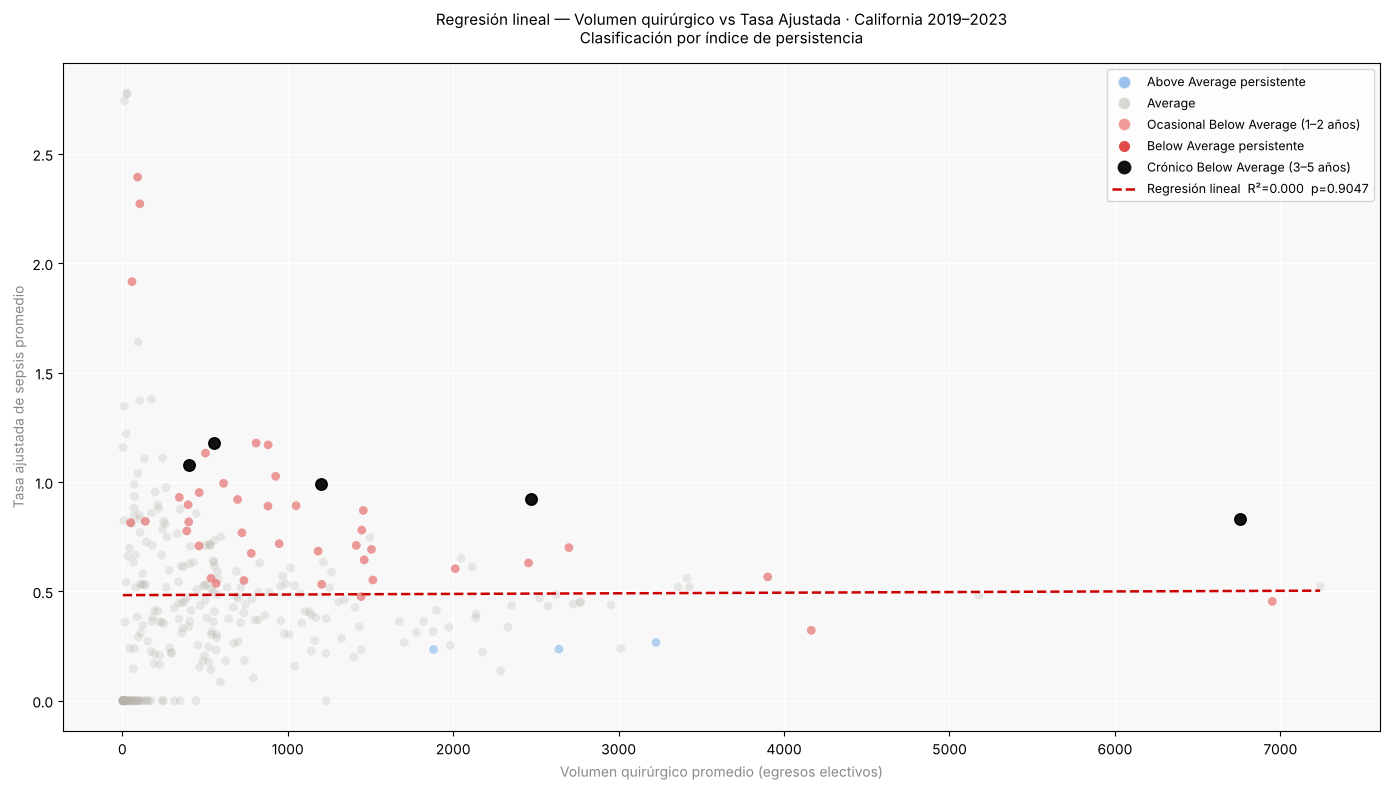

In [32]:
# ── Regresión lineal — Volumen vs Tasa Ajustada ───────────────────────
from scipy import stats

idx = persistencia[['volumen','tasa']].dropna().index
x = persistencia.loc[idx, 'volumen']
y = persistencia.loc[idx, 'tasa']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r2 = r_value**2

print(f"Pendiente:        {slope:.6f}")
print(f"Intercepto:       {intercept:.4f}")
print(f"R²:               {r2:.4f}")
print(f"p-value:          {p_value:.4f}")
print(f"Error estándar:   {std_err:.6f}")

# ── Gráfico ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_facecolor('#F8F8F8')

orden = ['average', 'cronico_above', 'ocasional_below', 'cronico_below']

COLORES = {
    'cronico_above':   '#378ADD',
    'average':         '#B4B2A9',
    'ocasional_below': '#E24B4A',
    'cronico_below':   '#E24B4A',
}

ALPHAS = {
    'cronico_above':   0.35,
    'average':         0.25,
    'ocasional_below': 0.55,
    'cronico_below':   1.0,
}

for g in orden:
    sub = persistencia[persistencia['grupo'] == g]
    ax.scatter(
        sub['volumen'], sub['tasa'],
        c=COLORES[g], alpha=ALPHAS[g],
        edgecolors='none', s=40,
        zorder=orden.index(g) + 2
    )

cronicos = persistencia[persistencia['grupo'] == 'cronico_below']
ax.scatter(
    cronicos['volumen'], cronicos['tasa'],
    c='#111111', alpha=1.0,
    edgecolors='#000000', linewidths=1.2,
    s=65, zorder=10
)

x_line = np.linspace(x.min(), x.max(), 300)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='#CC0000', linewidth=1.8,
        linestyle='--', label=f'Regresión lineal  R²={r2:.3f}  p={p_value:.4f}')

ax.set_xlabel('Volumen quirúrgico promedio (egresos electivos)',
              fontsize=10, color='#888888')
ax.set_ylabel('Tasa ajustada de sepsis promedio',
              fontsize=10, color='#888888')
ax.set_title(
    'Regresión lineal — Volumen quirúrgico vs Tasa Ajustada · California 2019–2023\n'
    'Clasificación por índice de persistencia',
    fontsize=11, pad=14
)
ax.grid(color='white', linewidth=0.8)

from matplotlib.lines import Line2D
leyenda = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#378ADD',
           markersize=9, alpha=0.5, label='Above Average persistente'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#B4B2A9',
           markersize=9, alpha=0.5, label='Average'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A',
           markersize=9, alpha=0.55, label='Ocasional Below Average (1–2 años)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A',
           markersize=9, alpha=1.0, label='Below Average persistente'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#111111',
           markersize=11, label='Crónico Below Average (3–5 años)'),
    Line2D([0],[0], color='#CC0000', linewidth=1.8, linestyle='--',
           label=f'Regresión lineal  R²={r2:.3f}  p={p_value:.4f}'),
]
ax.legend(handles=leyenda, loc='upper right', fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.show()

## Segmentación por volumen — criterio de corte

La distribución del volumen quirúrgico en el dataset presenta una asimetría
marcada: media de 761 cirugías, mediana de 448 y un máximo de 7240,
un valor extremo muy alejado.

El percentil 25 se ubica en 107 cirugías y el percentil 75 en 981, lo que
muestra que la mayor concentración del dataset está por debajo de los
1000 egresos anuales.

Para explorar el comportamiento de los extremos se definen tres grupos
operativos:

**Bajo volumen** — menos de 200 cirugías — 106 hospitales.

**Volumen medio** — entre 200 y 2000 cirugías — 175 hospitales.

**Alto volumen** — más de 2000 cirugías — 31 hospitales.

**Estos puntos de corte son exploratorios y propios de este análisis.**
No se presentan como umbrales clínicamente validados. Se eligieron para
separar con claridad una cola de bajo volumen, un grupo central amplio y
una cola de alto volumen, y permitir comparar su comportamiento.


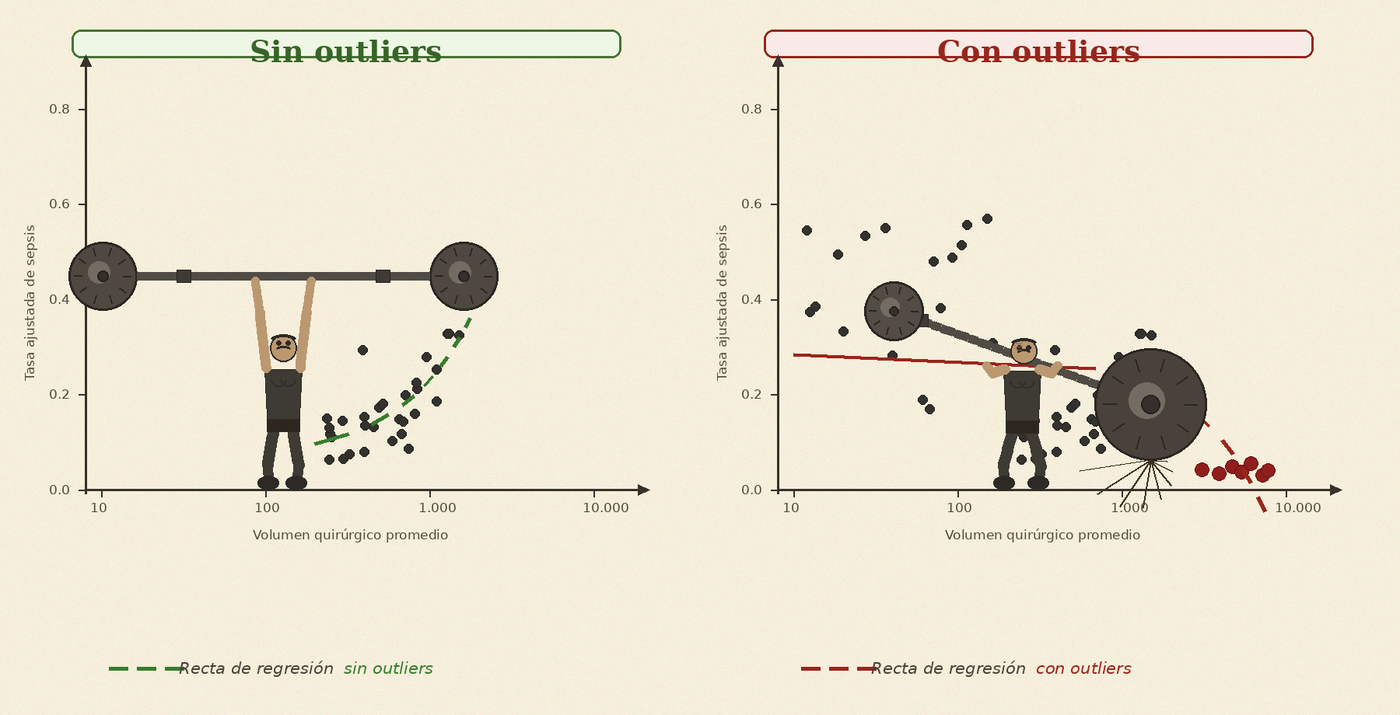

## El problema del peso de los extremos

La regresión lineal calcula una única recta minimizando el error
para *todos* los hospitales simultáneamente.

Los hospitales de muy bajo volumen tienen tasas ajustadas volátiles
—denominador pequeño, cualquier caso mueve el indicador de forma desproporcionada—
y tiran la recta hacia arriba.
Los de muy alto volumen tienen tasas sistemáticamente bajas
por su caracteristica de alta complejidad que el ajuste no captura del todo,
y tiran la recta hacia abajo con mucho más peso.

El resultado: la línea queda plana y R²≈0,
no porque no haya relación entre volumen y tasa,
sino porque los extremos se anulan entre sí
y arrastran con ellos a los hospitales del rango medio
donde la señal sí existe.


## Regresión lineal → Regresión múltiple

La **regresión lineal** sobre el dataset completo dio R²≈0 y p=0.90. La línea quedó plana — no porque no haya relación, sino porque los hospitales de volumen **extremo** rompen el modelo. Sus errores son demasiado grandes e impredecibles. Los del centro quedan aplastados por ese peso. Eso es **heterocedasticidad**: el modelo no se equivoca igual en todos lados, se equivoca mucho más en los extremos.

*(R²: proporción de la varianza de Y explicada por el modelo — valor 0 indica que el modelo no explica nada. p=0.90: probabilidad del 90% de que la pendiente observada sea producto del azar — muy por encima del umbral de significancia p<0.05.)*

La solución es separar los tres grupos y dejar que cada uno hable con su propia voz. Dentro de cada grupo, el *índice de persistencia* entra como segundo predictor — y eso convierte el análisis en una **regresión lineal múltiple**.


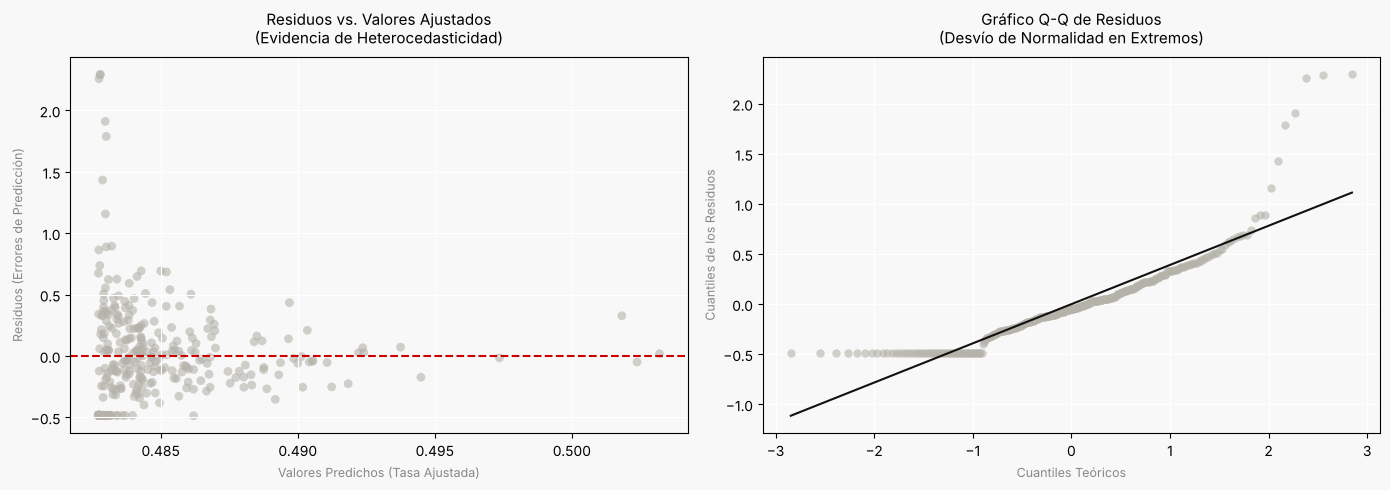

In [33]:
# ── Gráficos de diagnóstico: Residuos y Normalidad ──────────────────
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# Re-extraemos y aseguramos x e y numéricos desde el DataFrame de persistencia
idx_diag = persistencia[['volumen', 'tasa']].dropna().index
x_num = persistencia.loc[idx_diag, 'volumen'].values
y_num = persistencia.loc[idx_diag, 'tasa'].values

# Calculamos la regresión localmente para evitar variables contaminadas
slope_diag, intercept_diag, _, _, _ = stats.linregress(x_num, y_num)

# Calcular los valores predichos y los residuos de forma segura
valores_predichos = slope_diag * x_num + intercept_diag
residuos = y_num - valores_predichos

# Generar la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.set_facecolor('#F8F8F8')

# 1. Gráfico de Residuos vs Valores Ajustados (Heterocedasticidad)
ax1.scatter(valores_predichos, residuos, color='#B4B2A9', alpha=0.6, edgecolors='none', s=40)
ax1.axhline(0, color='#CC0000', linestyle='--', linewidth=1.5)
ax1.set_title('Residuos vs. Valores Ajustados\n(Evidencia de Heterocedasticidad)', fontsize=11, pad=10)
ax1.set_xlabel('Valores Predichos (Tasa Ajustada)', fontsize=9, color='#888888')
ax1.set_ylabel('Residuos (Errores de Predicción)', fontsize=9, color='#888888')
ax1.set_facecolor('#F8F8F8')
ax1.grid(color='white', linewidth=0.8)

# 2. Gráfico Q-Q Plot (Normalidad de Residuos)
stats.probplot(residuos, dist="norm", plot=ax2)

# Personalización estética para mantener la línea de diseño del notebook
ax2.get_lines()[0].set_markerfacecolor('#B4B2A9')
ax2.get_lines()[0].set_markeredgecolor('none')
ax2.get_lines()[0].set_alpha(0.6)
ax2.get_lines()[1].set_color('#111111')
ax2.get_lines()[1].set_linewidth(1.5)

ax2.set_title('Gráfico Q-Q de Residuos\n(Desvío de Normalidad en Extremos)', fontsize=11, pad=10)
ax2.set_xlabel('Cuantiles Teóricos', fontsize=9, color='#888888')
ax2.set_ylabel('Cuantiles de los Residuos', fontsize=9, color='#888888')
ax2.set_facecolor('#F8F8F8')
ax2.grid(color='white', linewidth=0.8)

plt.tight_layout()
plt.show()

### Comprobación de las condiciones de validez de la regresión global

* **Gráfico de Residuos vs. Valores Ajustados:** permite evaluar visualmente la condición de varianza constante. La forma observada **sugiere heterocedasticidad**, especialmente hacia los extremos, por lo que la varianza del error podría no ser uniforme.
* **Gráfico Q-Q de Residuos:** muestra desvíos en las colas y sugiere que los residuos no siguen perfectamente una distribución normal. Esto refuerza la cautela frente a una única aproximación lineal.

Estas observaciones son diagnósticos visuales; no constituyen por sí solas una prueba formal de heterocedasticidad o no normalidad.


## Regresión estratificada — tres grupos por volumen quirúrgico

La regresión sobre el dataset completo demostró que una sola recta
no puede representar a 312 hospitales que operan en condiciones
completamente distintas entre sí.

El criterio de segmentación va a estar definido sobre la distribución
real del dataset: bajo volumen (menos de 200 cirugías, 106 hospitales),
volumen medio (200 a 2000 cirugías, 175 hospitales)
y alto volumen (más de 2000 cirugías, 31 hospitales).

El grupo de bajo volumen tiene denominadores pequeños —
cualquier caso mueve el indicador de forma desproporcionada.

El grupo de alto volumen concentra los centros de referencia regional
con casos complejos de  que el ajuste no interpreta totalmente

El grupo medio es donde la tasa ajustada opera dentro
de sus condiciones de validez.

el objetivo de la segmentacion es establecer si de froma parcial la tasa volumen-tasa ajustada responde de froma diferente segun el nivel de volumen propuesto


In [34]:
# ── Segmentación en tres grupos por volumen ───────────────────────────
def segmento_volumen(v):
    if v < 200:     return 'bajo'
    elif v <= 2000: return 'medio'
    else:           return 'alto'

persistencia['segmento'] = persistencia['volumen'].apply(segmento_volumen)

print("Distribución por segmento:")
print(persistencia['segmento'].value_counts())

Distribución por segmento:
segmento
medio    175
bajo     106
alto      31
Name: count, dtype: int64


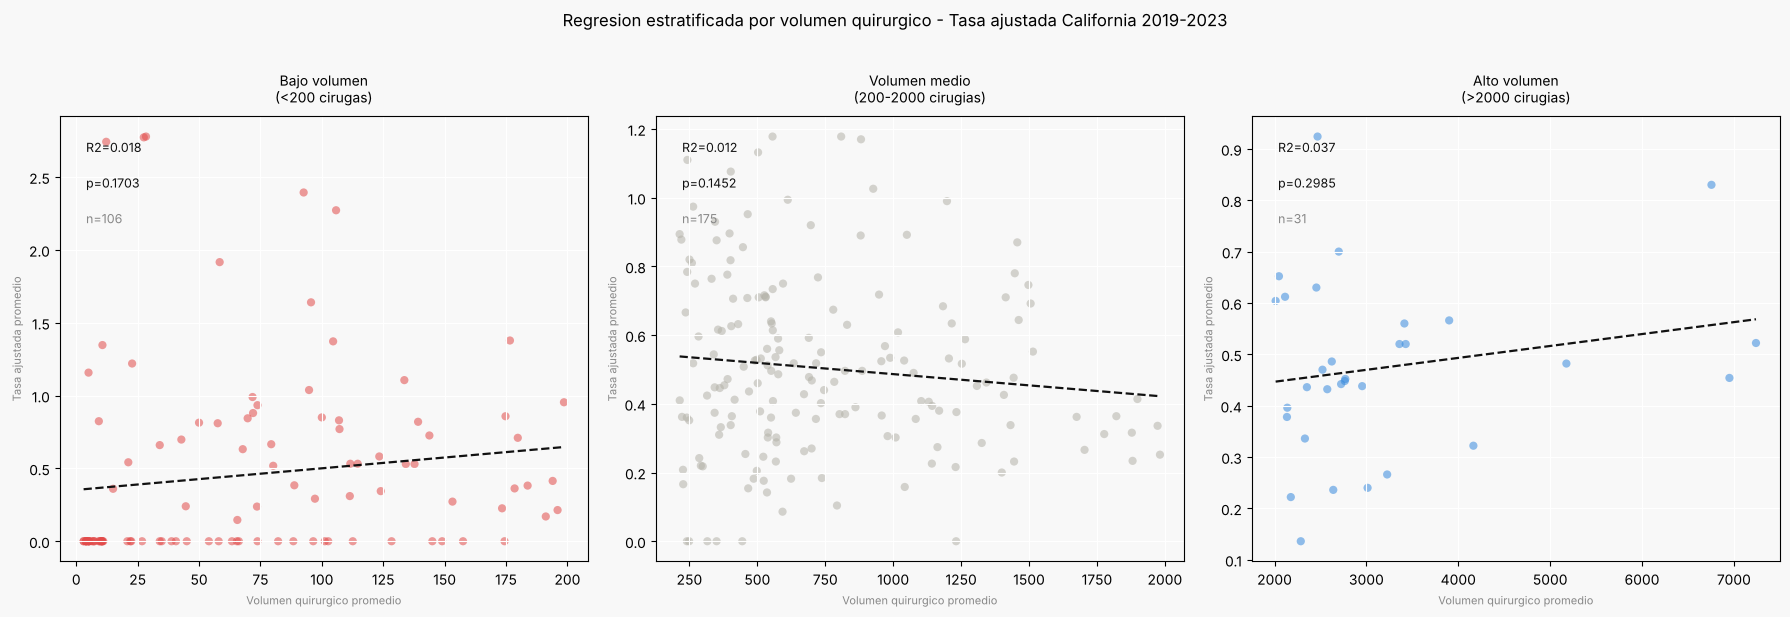


BAJO
  n=106  |  R2=0.0180  |  p=0.1703
  Pendiente=0.001482  |  Intercepto=0.3524

MEDIO
  n=175  |  R2=0.0122  |  p=0.1452
  Pendiente=-0.000065  |  Intercepto=0.5520

ALTO
  n=31  |  R2=0.0372  |  p=0.2985
  Pendiente=0.000023  |  Intercepto=0.4001


In [35]:
# Regresion estratificada — tres grupos
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.set_facecolor('#F8F8F8')

segmentos = [
    ('bajo',  'Bajo volumen\n(<200 cirugas)',      '#E24B4A'),
    ('medio', 'Volumen medio\n(200-2000 cirugias)', '#B4B2A9'),
    ('alto',  'Alto volumen\n(>2000 cirugias)',     '#378ADD'),
]

resultados = {}

for ax, (seg, titulo, color) in zip(axes, segmentos):
    sub = persistencia[persistencia['segmento'] == seg][['volumen','tasa']].dropna()
    x = sub['volumen'].values
    y = sub['tasa'].values

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r2 = r_value**2
    resultados[seg] = dict(slope=slope, intercept=intercept,
                           r2=r2, p_value=p_value, std_err=std_err, n=len(x))

    ax.set_facecolor('#F8F8F8')
    ax.scatter(x, y, color=color, alpha=0.55, edgecolors='none', s=35)

    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept,
            color='#111111', linewidth=1.6, linestyle='--')

    ax.set_title(titulo, fontsize=10, pad=10)
    ax.set_xlabel('Volumen quirurgico promedio', fontsize=8, color='#888888')
    ax.set_ylabel('Tasa ajustada promedio', fontsize=8, color='#888888')
    ax.grid(color='white', linewidth=0.8)

    ax.text(0.05, 0.92, f'R2={r2:.3f}', transform=ax.transAxes,
            fontsize=9, color='#111111')
    ax.text(0.05, 0.84, f'p={p_value:.4f}', transform=ax.transAxes,
            fontsize=9, color='#111111')
    ax.text(0.05, 0.76, f'n={len(x)}', transform=ax.transAxes,
            fontsize=9, color='#888888')

fig.suptitle(
    'Regresion estratificada por volumen quirurgico - Tasa ajustada California 2019-2023',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

for seg, res in resultados.items():
    print(f"\n{seg.upper()}")
    print(f"  n={res['n']}  |  R2={res['r2']:.4f}  |  p={res['p_value']:.4f}")
    print(f"  Pendiente={res['slope']:.6f}  |  Intercepto={res['intercept']:.4f}")

## **Conclusión**

En el grupo de volumen medio, la regresión muestra:

**R²=0.012 · p=0.145 · pendiente=-0.000065 · n=175**

Un R² bajo indica que el volumen quirúrgico explica muy poco de la variación
de la tasa ajustada dentro de este grupo. El p-value de 0.145 —por encima
del umbral convencional de 0.05— indica que no encontramos evidencia
suficiente de una relación lineal entre volumen y tasa.

Esto es compatible con la idea de que, en el rango medio, la tasa no está
dominada por el tamaño institucional. **No alcanza, sin embargo, para
demostrar por sí solo que la tasa mida calidad de manera perfecta.**

En bajo volumen ocurre algo similar:
*(R²=0.018 · p=0.170 · n=106)*. El denominador pequeño es una explicación
estadísticamente plausible para una mayor inestabilidad, pero este análisis
no mide directamente la precisión del indicador.

En alto volumen:
*(R²=0.037 · p=0.299 · n=31)*. Tampoco aparece una relación lineal
significativa. Es clínicamente razonable pensar que algunos grandes centros
tengan un case-mix más complejo, pero esas variables no están disponibles
en el dataset; por lo tanto esa explicación queda como **hipótesis**, no
como hallazgo demostrado.

**Conclusión de esta etapa:** probado por separado en los tres segmentos,
el volumen quirúrgico no predice de forma confiable la tasa ajustada.
Esto no invalida el indicador; delimita lo que podemos afirmar con estos
datos y justifica explorar otras dimensiones, como la persistencia temporal.


## Próximo paso: regresión polinómica de segundo orden

Los resultadosdel analsis siempre dieron líneas rectas para describir la relación entre volumen quirúrgico y tasa ajustada. Una línea recta solo puede hacer una cosa: subir, bajar o quedarse plana. Cuando los datos tienen forma de curva, la línea recta promedia todo y devuelve una pendiente plana. No es un error: es una **limitación del instrumento**.

Atento a esto se aplicara una regresion de tipo polinomica para detectar relaciones que las rectas no pudieron establecer

Polinómica significa que en lugar de usar solo el volumen para predecir la tasa, usamos el volumen y el volumen multiplicado por sí mismo al mismo tiempo. Ese segundo ingrediente — el volumen al cuadrado — es el que le da al modelo la capacidad de doblarse y seguir la forma real de los datos.

Segundo orden significa que se usan dos ingredientes: el volumen y el volumen multiplicado por sí mismo.  Una curva simple alcanza para demostrarlo.

Lo que sigue es ese modelo aplicado al dataset completo.


## Por qué escala logarítmica

La mayoría de los hospitales opera entre 0 y 2000 cirugías,
pero unos pocos superan las 5000. Esa desigualdad aplana la curva
porque los valores extremos pesan demasiado.

El logaritmo **comprime** esas distancias sin eliminar ningún dato,
permitiendo que el modelo detecte la forma real de la relación.


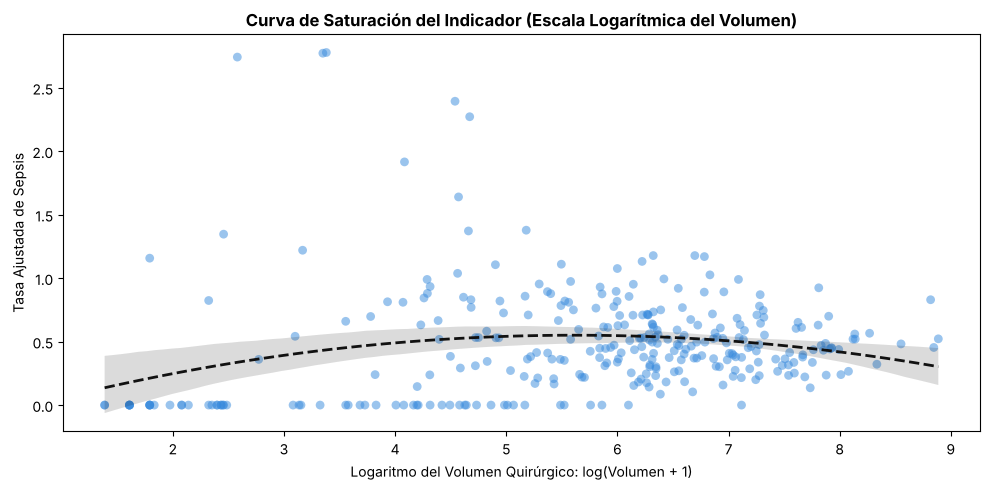

-----------------------------------------------------------------
MÉTRICAS DEL MODELO POLINÓMICO GLOBAL (LOG-ESCALA):
  R² cuadrático global: 0.0436
  Ecuación matemática: y = -0.023141*(log_vol)² + (0.2599)*log_vol + (-0.1795)
-----------------------------------------------------------------


In [36]:
# ==============================================================================
# EVALUACIÓN DE TENDENCIA NO LINEAL SOBRE ESCALA LOGARÍTMICA
# ==============================================================================
plt.figure(figsize=(10, 5))

# 1. Transformación logarítmica para corregir la asimetría y el outlier
datos_poly = persistencia[['volumen', 'tasa']].dropna().copy()
datos_poly['log_volumen'] = np.log1p(datos_poly['volumen'])

x_poly = datos_poly['log_volumen']
y_poly = datos_poly['tasa']

# 2. Graficar los datos expandidos y la curva parabólica con Seaborn
sns.scatterplot(x=x_poly, y=y_poly, alpha=0.5, color='#378ADD', edgecolor='none', s=40)
sns.regplot(x=x_poly, y=y_poly, scatter=False, order=2,
            color='#111111', line_kws={'linestyle': '--', 'linewidth': 2})

plt.title('Curva de Saturación del Indicador (Escala Logarítmica del Volumen)', fontsize=12, fontweight='bold')
plt.xlabel('Logaritmo del Volumen Quirúrgico: log(Volumen + 1)')
plt.ylabel('Tasa Ajustada de Sepsis')
plt.tight_layout()
plt.show()

# 3. Tu propuesta: Cálculo analítico complementario usando NumPy sobre la nueva escala
coefs = np.polyfit(x_poly, y_poly, 2)
p = np.poly1d(coefs)

# Cálculo del R² para el modelo cuadrático logarítmico
ss_res = np.sum((y_poly - p(x_poly))**2)
ss_tot = np.sum((y_poly - y_poly.mean())**2)
r2_poly = 1 - (ss_res / ss_tot)

# Consola de resultados limpios
print("-" * 65)
print(f"MÉTRICAS DEL MODELO POLINÓMICO GLOBAL (LOG-ESCALA):")
print(f"  R² cuadrático global: {r2_poly:.4f}")
print(f"  Ecuación matemática: y = {coefs[0]:.6f}*(log_vol)² + ({coefs[1]:.4f})*log_vol + ({coefs[2]:.4f})")
print("-" * 65)

## Lo que la curva sugiere

El modelo polinómico sobre escala logarítmica arroja R²=0.0436
y dibuja una cúpula: la tasa ajustada sube en el rango intermedio
y desciende hacia los extremos.

Visualmente, esta forma resulta interesante y podría sugerir una relación
no lineal. Sin embargo, con un R² tan bajo no corresponde interpretarla
todavía como una propiedad real del indicador.

Antes de aceptar esa lectura se valida si la forma se sostiene fuera
de la muestra que la generó. Este paso es clave: si no generaliza,
la cúpula debe considerarse ruido o ajuste específico de esta muestra.


## Validación fuera de muestra — ¿la cúpula es real o es ruido?

El modelo polinómico de la celda anterior fue ajustado y se revisó usando a los
mismos 312 hospitales, todos juntos.
El problema es que así no
hay forma de saber si esa forma de cúpula es algo real que pasa
en cualquier grupo de hospitales, o si es solo una casualidad de
estos 312 en particular —

Se aplica una validación
train/test: el modelo se entrena con el 70% de los hospitales
y se evalúa sobre el 30% restante, que nunca participó del ajuste.

Si el R² se mantiene similar en ambos conjuntos, la cúpula
representa un patrón real, aunque débil. Si el R² colapsa en el
conjunto de prueba, la forma observada responde al ruido propio
de estos 312 hospitales y no a una relación generalizable.


In [37]:
# ==============================================================================
# VALIDACIÓN FUERA DE MUESTRA — MODELO POLINÓMICO (LOG-ESCALA)
# Objetivo: confirmar si la forma de cúpula (R²=0.0436) es un patrón
# generalizable o un ajuste al ruido específico de estos 312 hospitales.
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Mismos datos y misma transformación logarítmica que la celda 87
datos_val = persistencia[['volumen', 'tasa']].dropna().copy()
datos_val['log_volumen'] = np.log1p(datos_val['volumen'])

X = datos_val[['log_volumen']]
y = datos_val['tasa']

# División 70/30 — random_state fijo para que el resultado sea reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Mismo polinomio de grado 2 ajustado únicamente sobre el conjunto de entrenamiento
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

modelo_val = LinearRegression()
modelo_val.fit(X_train_poly, y_train)

r2_train = r2_score(y_train, modelo_val.predict(X_train_poly))
r2_test = r2_score(y_test, modelo_val.predict(X_test_poly))

print("-----------------------------------------------------------------")
print("VALIDACIÓN TRAIN/TEST — MODELO POLINÓMICO GLOBAL (LOG-ESCALA):")
print(f"  R² en entrenamiento (n={len(X_train)}): {r2_train:.4f}")
print(f"  R² en prueba        (n={len(X_test)}):  {r2_test:.4f}")
print("-----------------------------------------------------------------")

-----------------------------------------------------------------
VALIDACIÓN TRAIN/TEST — MODELO POLINÓMICO GLOBAL (LOG-ESCALA):
  R² en entrenamiento (n=218): 0.0373
  R² en prueba        (n=94):  0.0639
-----------------------------------------------------------------


## Validación fuera de muestra — la cúpula no se sostiene

Atento a que el R²=0.0436 de la celda anterior fue calculado sobre
los mismos 312 hospitales que se usaron para armar el modelo,
correspondía verificar si esa cúpula era una relación real o
simplemente el polinomio ajustándose a particularidades de esta
muestra puntual.

Un primer corte train/test (70% entrenamiento, 30% prueba) pareció
sostener el resultado: R²=0.0373 en entrenamiento y R²=0.0639 en
prueba. Pero un solo corte puede tener suerte, así que se repitió
la prueba con validación cruzada K-Fold —5 cortes distintos,
promediados— para descartar esa posibilidad.

**R² por fold: -0.0079, 0.0215, -0.0286, 0.0125, 0.0087**
**R² promedio: 0.0012**

El resultado cambia. Dos de los cinco cortes salen negativos, y el
promedio queda prácticamente en cero. Esto indica que la forma de
cúpula no es un patrón real del fenómeno, sino el resultado de que
el primer corte 70/30 cayó, por azar, en una combinación favorable.

Esta conclusión es consistente con el resto del análisis: la
regresión lineal global (R²≈0, p=0.90) y las tres regresiones por
segmento de volumen (bajo, medio y alto, todas con p>0.05) ya
habían mostrado que el volumen no predice la tasa ajustada de
forma confiable. El polinomio parecía romper esa tendencia, pero
bajo validación cruzada queda alineado con el resto: probado de
cinco formas distintas, el volumen quirúrgico no explica de manera
confiable la variación de la tasa ajustada.

**Esto no descalifica a la tasa ajustada como indicador.** Lo que se descarta es
que el volumen, como variable aislada, sirva para predecir de manera
confiable esa tasa. El resultado obliga a moderar la hipótesis inicial:
con estos datos no puede demostrarse que el indicador pierda validez en
los extremos, pero sí puede sostenerse que el volumen por sí solo no explica
su comportamiento. La persistencia se mantiene como una dimensión temporal
complementaria que será evaluada por separado.


In [38]:
# ==============================================================================
# VALIDACIÓN CRUZADA K-FOLD — MODELO POLINÓMICO (LOG-ESCALA)
# Objetivo: confirmar el resultado de la validación train/test repitiendo
# la evaluación con 5 cortes distintos, para descartar que el resultado
# dependa de la suerte de un único corte de datos.
# ==============================================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Mismos datos que la validación train/test
datos_val = persistencia[['volumen', 'tasa']].dropna().copy()
datos_val['log_volumen'] = np.log1p(datos_val['volumen'])

X = datos_val[['log_volumen']]
y = datos_val['tasa']

# Pipeline: mismo polinomio de grado 2 aplicado dentro de cada fold
modelo_kfold = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

# 5 cortes distintos, evaluados con R²
scores = cross_val_score(modelo_kfold, X, y, cv=5, scoring='r2')

print("-----------------------------------------------------------------")
print("VALIDACIÓN K-FOLD (5 cortes) — MODELO POLINÓMICO GLOBAL:")
print(f"  R² por fold: {np.round(scores, 4)}")
print(f"  R² promedio: {scores.mean():.4f}")
print(f"  Desvío entre folds: {scores.std():.4f}")
print("-----------------------------------------------------------------")

-----------------------------------------------------------------
VALIDACIÓN K-FOLD (5 cortes) — MODELO POLINÓMICO GLOBAL:
  R² por fold: [-0.0079  0.0215 -0.0286  0.0125  0.0087]
  R² promedio: 0.0012
  Desvío entre folds: 0.0177
-----------------------------------------------------------------


## Recomendación Operativa: Modelo de Auditoría Segmentado

El análisis deja un resultado consistente: el volumen quirúrgico, probado
mediante regresión global, regresiones estratificadas y una relación
polinómica sometida a validación cruzada, **no predice de manera confiable
la tasa ajustada**.

Por eso las recomendaciones siguientes deben leerse como propuestas de
auditoría para evaluación futura, no como cambios normativos ya validados.

**Hospitales de bajo volumen — menos de 200 egresos electivos anuales.**
Podría evaluarse el uso de un promedio móvil de tres años para reducir la
variabilidad asociada a un número pequeño de eventos. Esta propuesta debería
compararse formalmente contra el indicador anual antes de adoptarse.

**Hospitales de volumen medio — entre 200 y 2000 egresos.**
En este grupo no se observó una relación lineal significativa entre volumen
y tasa. Puede mantenerse el criterio vigente, complementándolo con seguimiento
temporal cuando existan episodios repetidos.

**Hospitales de alto volumen — más de 2000 egresos.**
No se observó una relación lineal significativa. Dado que el dataset no
incluye todas las variables de complejidad clínica, sería razonable incorporar
en futuras auditorías información adicional sobre urgencias, oncología,
inmunosupresión, especialidades de alto riesgo y condiciones estructurales
antes de atribuir una clasificación desfavorable exclusivamente a calidad.

La segmentación 200/2000 es exploratoria y sirve para organizar el análisis;
no se propone como umbral clínico universal.


## Conclusión

Este enfoque transforma una lectura única del indicador en una
**estrategia de auditoría más contextual**, guiada por lo que los datos
permiten afirmar y también por lo que no permiten demostrar.

**La creación del ÍNDICE DE PERSISTENCIA sigue siendo el aporte diferencial
del trabajo:** incorpora la dimensión temporal y permite distinguir un
episodio aislado de un patrón repetido, sin pretender reemplazar a la tasa
ajustada.


## Etapa de modelado — qué busca confirmar

El EDA dejó planteada una hipótesis: algunos hospitales alejados del rango
central podrían requerir una lectura adicional del indicador.
Los modelos de regresión mostraron algo más concreto: **el volumen, por sí
solo, no explica de manera confiable la tasa ajustada**.

Esta etapa de Machine Learning busca otra cosa: evaluar si los segmentos
de volumen —bajo, medio y alto— pueden identificarse a partir de la tasa
ajustada promedio y del ***índice de persistencia***.

No busca predecir la tasa —la tasa ya es la salida de un modelo previo—.
Tampoco pretende demostrar causalidad. Es un modelo exploratorio de
clasificación y su valor dependerá de su rendimiento fuera del conjunto
de entrenamiento.

El objetivo es el segmento de volumen, definido previamente de forma
exploratoria. Los predictores son el ***índice de persistencia*** y la
tasa ajustada promedio.


## Preparación — variables del modelo

Se trabaja sobre `persistencia`: un hospital, una fila.

Predictores: ***índice de persistencia*** (`below_years`, `above_years`) y
tasa ajustada promedio. Objetivo: el segmento de volumen.

El volumen no entra como predictor — el segmento se define por él, usarlo
sería circular.


In [39]:
datos_ml = persistencia[['below_years', 'above_years', 'tasa', 'segmento']].dropna().copy()

X = datos_ml[['below_years', 'above_years', 'tasa']]
y = datos_ml['segmento']

print(f"Hospitales: {len(datos_ml)}")
print(datos_ml['segmento'].value_counts())

Hospitales: 312
segmento
medio    175
bajo     106
alto      31
Name: count, dtype: int64


## División en entrenamiento y prueba

Los tres segmentos tienen tamaños muy distintos — bajo 106, medio 175,
alto 31. Con `stratify` se mantiene esa proporción en ambos conjuntos,
para que el grupo alto no desaparezca de la prueba.


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## Modelo — árbol de decisión

Se elige un árbol de decisión porque es interpretable y permite observar
cómo utiliza cada variable para separar los grupos.

`max_depth=3` limita la profundidad como estrategia de regularización:
reduce el riesgo de sobreajuste y mantiene el modelo legible.
**No garantiza por sí solo que el modelo generalice**, por lo que a
continuación se evalúa su desempeño sobre el conjunto de prueba y mediante
validación cruzada.


In [41]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in

Accuracy test:          0.746
Balanced accuracy test: 0.521

Reporte por clase:
              precision    recall  f1-score   support

        alto      0.000     0.000     0.000         6
        bajo      0.929     0.591     0.722        22
       medio      0.694     0.971     0.810        35

    accuracy                          0.746        63
   macro avg      0.541     0.521     0.511        63
weighted avg      0.710     0.746     0.702        63

Matriz de confusión:
[[ 0  0  6]
 [ 0 13  9]
 [ 0  1 34]]


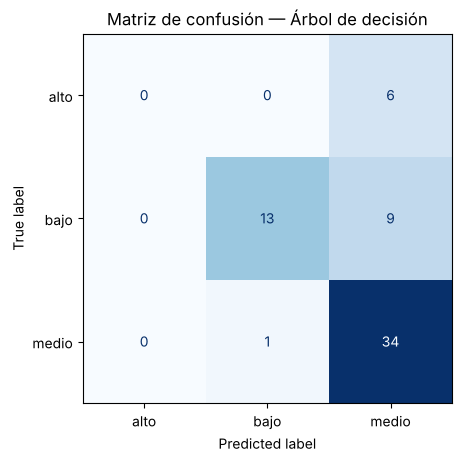


Balanced accuracy por fold: 0.557, 0.492, 0.483, 0.498, 0.537
Balanced accuracy CV promedio: 0.513 ± 0.028


In [42]:
# ── Evaluación del árbol: conjunto de prueba y validación cruzada ─────────────
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt

y_pred = modelo.predict(X_test)

acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Accuracy test:          {acc:.3f}")
print(f"Balanced accuracy test: {bal_acc:.3f}")
print("\nReporte por clase:")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred, labels=modelo.classes_))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=modelo.classes_, cmap='Blues', colorbar=False
)
disp.ax_.set_title('Matriz de confusión — Árbol de decisión')
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_bal = cross_val_score(modelo, X, y, cv=cv, scoring='balanced_accuracy')

print("\nBalanced accuracy por fold:",
      ", ".join(f"{v:.3f}" for v in cv_bal))
print(f"Balanced accuracy CV promedio: {cv_bal.mean():.3f} ± {cv_bal.std():.3f}")


### Lectura de la evaluación

Como los tres segmentos tienen tamaños diferentes, la **balanced accuracy**
es más informativa que la accuracy sola: da el mismo peso a cada clase.

La matriz de confusión y el reporte por clase permiten ver especialmente
qué ocurre con el grupo de alto volumen, que es el menos numeroso.

La conclusión sobre si los segmentos son realmente “identificables” debe
basarse en estos resultados y no sólo en la importancia de las variables.


## Importancia de las variables — qué puede y qué no puede confirmar

El árbol asigna un peso a cada variable según cuánto contribuye a separar
los grupos dentro del modelo.

La importancia de Gini ayuda a interpretar qué variables utiliza el árbol,
pero **no demuestra causalidad ni garantiza que la clasificación sea buena**.
Por eso debe leerse junto con la matriz de confusión, precision, recall,
F1 y la validación cruzada.

Si el ***índice de persistencia*** aporta peso, significa que agrega
información al modelo; su utilidad real depende del rendimiento global
del clasificador.


In [43]:
import pandas as pd

importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

print(importancias.to_string(index=False))

   variable  importancia
       tasa     0.900086
above_years     0.099914
below_years     0.000000


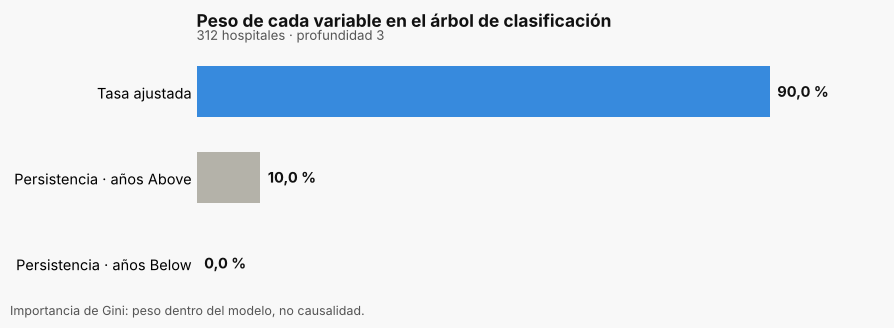

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Nombres legibles para el gráfico
etiquetas = {
    'tasa': 'Tasa ajustada',
    'above_years': 'Persistencia · años Above',
    'below_years': 'Persistencia · años Below'
}

# Importancias del árbol ya entrenado (orden ascendente: la dominante queda arriba)
imp = (pd.DataFrame({'variable': X.columns,
                     'importancia': modelo.feature_importances_})
       .sort_values('importancia'))
imp['etiqueta'] = imp['variable'].map(etiquetas)
imp['color'] = imp['variable'].apply(lambda v: '#378ADD' if v == 'tasa' else '#B4B2A9')

fig, ax = plt.subplots(figsize=(9, 3.2))
fig.set_facecolor('#F8F8F8')
ax.set_facecolor('#F8F8F8')

ax.barh(imp['etiqueta'], imp['importancia'], color=imp['color'], height=0.6)

# Valor sobre TODAS las barras, incluido el 0,0 %
for y, val in enumerate(imp['importancia']):
    ax.text(val + 0.012, y, f'{val*100:.1f} %'.replace('.', ','),
            va='center', ha='left', fontsize=10.5, fontweight='bold', color='#111111')

ax.set_title('Peso de cada variable en el árbol de clasificación',
             fontsize=12.5, fontweight='bold', loc='left', color='#111111', pad=20)
ax.text(0, 1.06, '312 hospitales · profundidad 3', transform=ax.transAxes,
        fontsize=9.5, color='#555555', ha='left')

ax.set_xlim(0, 1.08)
ax.set_xticks([])
ax.tick_params(axis='y', length=0, labelsize=10.5)
for s in ax.spines.values():
    s.set_visible(False)

fig.text(0.012, 0.0, 'Importancia de Gini: peso dentro del modelo, no causalidad.',
         fontsize=9, color='#555555', ha='left')

plt.tight_layout()
plt.show()

## Lo que muestra el gráfico

El árbol tenía tres variables para elegir y se quedó casi entero con una:
la tasa ajustada concentra alrededor del 90 % de la importancia interna;
la persistencia —años Above— aporta aproximadamente un 10 %, y los años
Below prácticamente no participan en las decisiones del árbol.

Yo había armado el ***índice de persistencia*** pensando que iba a pesar
fuerte. No pesó como esperaba, y está bien que el análisis lo muestre.
La persistencia no mide tamaño: mide si un desempeño se repite en el tiempo.

La importancia de variables no alcanza para juzgar el modelo. La lectura
final debe combinar este gráfico con la matriz de confusión, las métricas
por clase y la balanced accuracy obtenidas en la evaluación anterior.


## Comparativa de modelos de clasificación — requisito de la entrega final

La consigna pide **evaluar al menos dos algoritmos y justificar la elección final**. Hasta acá el trabajo tenía un solo clasificador: el árbol de decisión de profundidad 3.

Se comparan seis modelos con **el mismo protocolo**, los mismos predictores (`below_years`, `above_years`, `tasa`) y el mismo objetivo (segmento de volumen):

1. **Baseline de clase mayoritaria** — predice siempre "medio". Es el piso: cualquier modelo útil tiene que superarlo.
2. **Regresión logística** — modelo lineal de referencia, con pesos balanceados por clase.
3. **Árbol de decisión v11** — el modelo de la versión anterior, sin cambios.
4. **Árbol balanceado** — el mismo árbol de profundidad 3, con `class_weight='balanced'` para que el grupo alto (31 hospitales) no quede absorbido por el medio.
5. **Random Forest** — muchos árboles promediados, con pesos balanceados.
6. **XGBoost** — boosting de árboles, con pesos balanceados.

**Métrica principal:** *balanced accuracy*, porque las clases están desbalanceadas (175 / 106 / 31). **Complementarias:** precision, recall y F1 macro, ROC-AUC uno-contra-el-resto y accuracy.

**Validación:** el mismo corte 80/20 estratificado de la versión anterior (test de 63 hospitales) y validación cruzada estratificada de 5 folds con la misma semilla.

**Regla de selección:** gana el mejor promedio de balanced accuracy en validación cruzada; los modelos que quedan a menos de un desvío del mejor se consideran empatados, y entre los empatados se elige el más interpretable.

                      modelo  balanced_acc_CV  desvío  F1_macro_CV  ROC_AUC_CV  accuracy_CV
Baseline (clase mayoritaria)            0.333   0.000        0.240       0.500        0.561
         Regresión logística            0.505   0.056        0.373       0.593        0.407
       Árbol de decisión v11            0.513   0.028        0.501       0.756        0.737
            Árbol balanceado            0.588   0.068        0.591       0.744        0.689
               Random Forest            0.594   0.079        0.539       0.787        0.583
                     XGBoost            0.590   0.073        0.573       0.780        0.663

Mejor balanced accuracy CV: Random Forest (0.594 ± 0.079)
Empatados (a menos de un desvío): Árbol balanceado, Random Forest, XGBoost

Balanced accuracy por fold:
                              Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
Baseline (clase mayoritaria)   0.333   0.333   0.333   0.333   0.333
Regresión logística            0.517   0.444   0.594   

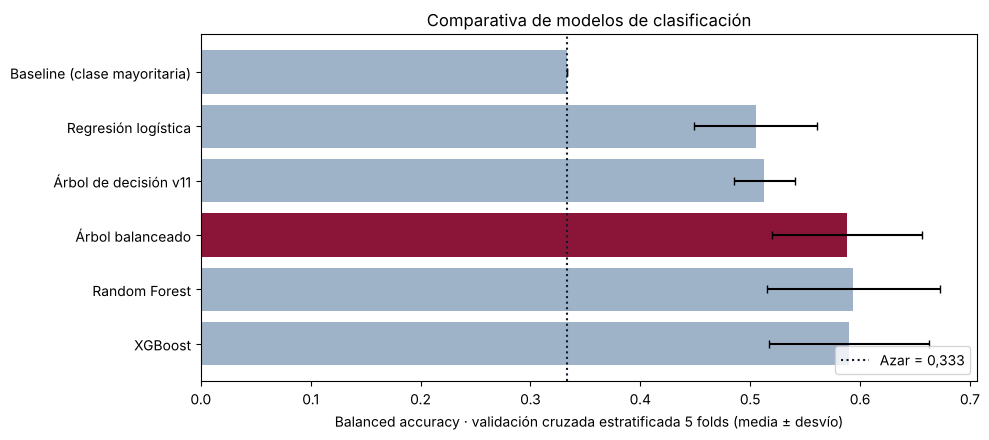

In [45]:
# ── Comparativa de modelos: validación cruzada estratificada 5 folds ──────────
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
from xgboost import XGBClassifier

# Se vuelven a fijar predictores y objetivo (la celda del gráfico de importancias reutiliza el nombre y)
X = datos_ml[['below_years', 'above_years', 'tasa']]
y = datos_ml['segmento']

# Los segmentos se pasan a números para que todos los modelos (incluido XGBoost) usen la misma etiqueta
codigos = {'alto': 0, 'bajo': 1, 'medio': 2}
nombres_clase = ['alto', 'bajo', 'medio']
y_num = y.map(codigos)

def crear_modelos():
    return {
        'Baseline (clase mayoritaria)': DummyClassifier(strategy='most_frequent'),
        'Regresión logística': make_pipeline(StandardScaler(),
                                             LogisticRegression(max_iter=1000, class_weight='balanced')),
        'Árbol de decisión v11': DecisionTreeClassifier(max_depth=3, random_state=42),
        'Árbol balanceado': DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                                class_weight='balanced', random_state=42),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                 subsample=0.9, random_state=42, eval_metric='mlogloss'),
    }

def entrenar(nombre, modelo, X_fit, y_fit):
    # XGBoost no tiene class_weight: se le pasan pesos por observación equivalentes
    if nombre == 'XGBoost':
        modelo.fit(X_fit, y_fit, sample_weight=compute_sample_weight('balanced', y_fit))
    else:
        modelo.fit(X_fit, y_fit)
    return modelo

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
filas_cv = []
folds_cv = {}

for nombre in crear_modelos().keys():
    bal, f1, auc, acc = [], [], [], []
    for idx_train, idx_val in cv.split(X, y_num):
        modelo = crear_modelos()[nombre]
        modelo = entrenar(nombre, modelo, X.iloc[idx_train], y_num.iloc[idx_train])
        pred = modelo.predict(X.iloc[idx_val])
        prob = modelo.predict_proba(X.iloc[idx_val])
        real = y_num.iloc[idx_val]
        bal.append(balanced_accuracy_score(real, pred))
        f1.append(f1_score(real, pred, average='macro'))
        auc.append(roc_auc_score(real, prob, multi_class='ovr', labels=[0, 1, 2]))
        acc.append(accuracy_score(real, pred))
    folds_cv[nombre] = np.round(bal, 3)
    filas_cv.append({'modelo': nombre,
                     'balanced_acc_CV': np.mean(bal), 'desvío': np.std(bal),
                     'F1_macro_CV': np.mean(f1), 'ROC_AUC_CV': np.mean(auc),
                     'accuracy_CV': np.mean(acc)})

tabla_cv = pd.DataFrame(filas_cv).round(3)
print(tabla_cv.to_string(index=False))

# Regla de selección: empatados = a menos de un desvío del mejor
mejor = tabla_cv.loc[tabla_cv['balanced_acc_CV'].idxmax()]
empatados = tabla_cv[mejor['balanced_acc_CV'] - tabla_cv['balanced_acc_CV'] <= mejor['desvío']]
print(f"\nMejor balanced accuracy CV: {mejor['modelo']} ({mejor['balanced_acc_CV']:.3f} ± {mejor['desvío']:.3f})")
print("Empatados (a menos de un desvío):", ', '.join(empatados['modelo']))

print("\nBalanced accuracy por fold:")
print(pd.DataFrame(folds_cv, index=['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']).T.to_string())

# Gráfico de la comparativa: media ± desvío, con la línea del azar (0,333)
fig, ax = plt.subplots(figsize=(10, 4.5))
posiciones = np.arange(len(tabla_cv))[::-1]
colores = ['#8A1538' if m == 'Árbol balanceado' else '#9FB3C8' for m in tabla_cv['modelo']]
ax.barh(posiciones, tabla_cv['balanced_acc_CV'], xerr=tabla_cv['desvío'], color=colores, capsize=3)
ax.axvline(1/3, color='#111827', linestyle=':', label='Azar = 0,333')
ax.set_yticks(posiciones)
ax.set_yticklabels(tabla_cv['modelo'])
ax.set_xlabel('Balanced accuracy · validación cruzada estratificada 5 folds (media ± desvío)')
ax.set_title('Comparativa de modelos de clasificación')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [46]:
# ── Comparativa de modelos: conjunto de prueba (mismo corte 80/20 de la versión anterior) ──
y_train_num = y_train.map(codigos)
y_test_num = y_test.map(codigos)

filas_test = []
modelos_entrenados = {}

for nombre, modelo in crear_modelos().items():
    modelo = entrenar(nombre, modelo, X_train, y_train_num)
    modelos_entrenados[nombre] = modelo
    pred = modelo.predict(X_test)
    prob = modelo.predict_proba(X_test)
    recall_clase = recall_score(y_test_num, pred, average=None, labels=[0, 1, 2], zero_division=0)
    filas_test.append({'modelo': nombre,
                       'accuracy': accuracy_score(y_test_num, pred),
                       'balanced_acc': balanced_accuracy_score(y_test_num, pred),
                       'precision_macro': precision_score(y_test_num, pred, average='macro', zero_division=0),
                       'recall_macro': recall_score(y_test_num, pred, average='macro'),
                       'F1_macro': f1_score(y_test_num, pred, average='macro'),
                       'ROC_AUC': roc_auc_score(y_test_num, prob, multi_class='ovr', labels=[0, 1, 2]),
                       'recall_alto': recall_clase[0], 'recall_bajo': recall_clase[1],
                       'recall_medio': recall_clase[2]})

tabla_test = pd.DataFrame(filas_test).round(3)
print(tabla_test.to_string(index=False))

                      modelo  accuracy  balanced_acc  precision_macro  recall_macro  F1_macro  ROC_AUC  recall_alto  recall_bajo  recall_medio
Baseline (clase mayoritaria)     0.556         0.333            0.185         0.333     0.238    0.500        0.000        0.000         1.000
         Regresión logística     0.476         0.502            0.467         0.502     0.413    0.638        0.333        1.000         0.171
       Árbol de decisión v11     0.746         0.521            0.541         0.521     0.511    0.750        0.000        0.591         0.971
            Árbol balanceado     0.714         0.594            0.653         0.594     0.608    0.750        0.333        0.591         0.857
               Random Forest     0.587         0.546            0.552         0.546     0.526    0.823        0.333        0.818         0.486
                     XGBoost     0.667         0.547            0.549         0.547     0.546    0.784        0.167        0.818         0.657

### Lectura de la comparativa y elección del modelo

- El **baseline** fija el piso: balanced accuracy 0,333 y ROC-AUC 0,500, que es lo mismo que adivinar.
- La **regresión logística** apenas supera el piso (0,505), porque la relación entre la tasa y el segmento no es lineal: los hospitales chicos aparecen en los dos extremos de la tasa.
- El **árbol v11** sostiene 0,513 ± 0,028, pero nunca predice el segmento alto (recall 0 en test).
- **Árbol balanceado, Random Forest y XGBoost** quedan empatados según la regla (0,588 – 0,594, con desvíos de 0,07 – 0,08).

**Modelo elegido: árbol balanceado de profundidad 3.** Está empatado con los modelos de ensamble, obtiene el mejor F1 macro en test (0,608) y la mejor balanced accuracy en test (0,594), y es el único de los empatados que se puede leer como un conjunto de reglas. Para auditar un indicador sanitario, entender **por qué** clasifica como clasifica vale más que un punto extra de ROC-AUC.

La señal sigue siendo **modesta**: todos los modelos quedan lejos de una clasificación confiable. Que la tasa ajustada no permita reconstruir bien el tamaño del hospital es coherente con lo que mostró la regresión.

              precision    recall  f1-score   support

        alto      0.333     0.333     0.333         6
        bajo      0.929     0.591     0.722        22
       medio      0.698     0.857     0.769        35

    accuracy                          0.714        63
   macro avg      0.653     0.594     0.608        63
weighted avg      0.744     0.714     0.711        63

ROC-AUC por clase (uno contra el resto):
  alto   0.713
  bajo   0.814
  medio  0.722

Reglas del árbol:
|--- tasa <= 0.04
|   |--- class: bajo
|--- tasa >  0.04
|   |--- above_years <= 0.50
|   |   |--- tasa <= 1.20
|   |   |   |--- class: medio
|   |   |--- tasa >  1.20
|   |   |   |--- class: bajo
|   |--- above_years >  0.50
|   |   |--- tasa <= 0.47
|   |   |   |--- class: alto
|   |   |--- tasa >  0.47
|   |   |   |--- class: medio

Importancia de las variables:
  below_years  0.000
  above_years  0.280
  tasa         0.720


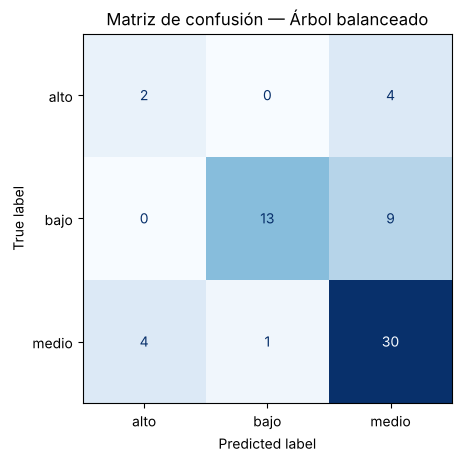

In [47]:
# ── Modelo elegido: árbol balanceado — evaluación detallada en test ─────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import export_text

modelo_final = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
modelo_final.fit(X_train, y_train)
pred_final = modelo_final.predict(X_test)
prob_final = modelo_final.predict_proba(X_test)

print(classification_report(y_test, pred_final, digits=3, zero_division=0))

print("ROC-AUC por clase (uno contra el resto):")
for i, clase in enumerate(modelo_final.classes_):
    auc_clase = roc_auc_score((y_test == clase).astype(int), prob_final[:, i])
    print(f"  {clase:6s} {auc_clase:.3f}")

print("\nReglas del árbol:")
print(export_text(modelo_final, feature_names=list(X.columns)))

print("Importancia de las variables:")
for variable, valor in zip(X.columns, modelo_final.feature_importances_):
    print(f"  {variable:12s} {valor:.3f}")

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, pred_final, labels=modelo_final.classes_, cmap='Blues', colorbar=False
)
disp.ax_.set_title('Matriz de confusión — Árbol balanceado')
plt.show()

### Qué aprendió el árbol: la firma del denominador pequeño

Las reglas del árbol son explícitas:

- **tasa ≤ 0,04 → bajo volumen.**
- **tasa > 1,20 → bajo volumen.**
- Con al menos un año Above Average y tasa ≤ 0,47 → alto volumen.
- El resto → volumen medio.

El árbol reconoce a los hospitales chicos porque su tasa cae en **los dos extremos**: con pocas cirugías, un solo caso de sepsis dispara la tasa y ningún caso la deja en cero. Es un efecto conocido en epidemiología: con denominadores pequeños, la tasa se vuelve inestable.

La celda siguiente cuantifica ese efecto directamente sobre los datos.

          hospitales  tasa_media  desvio_tasa  casos_sepsis  %_casos
segmento                                                            
bajo             106       0.458        0.651           152      2.7
medio            175       0.503        0.260          2728     48.3
alto              31       0.475        0.172          2771     49.0

Hospitales con tasa promedio ≤ 0,04: 57 | de bajo volumen: 51
Hospitales con tasa promedio > 1,20: 11 | de bajo volumen: 11

% de años-hospital con tasa = 0:
segmento
bajo     75.6
medio    16.7
alto      1.9
Name: Risk-adjusted Postoperative Sepsis Rate, dtype: float64

% de calificaciones por segmento (años-hospital):
Risk-adjustedAveragePerformanceAverageRating  Above Average  Average  \
segmento                                                               
bajo                                                    0.0     98.7   
medio                                                   2.7     92.2   
alto                                        

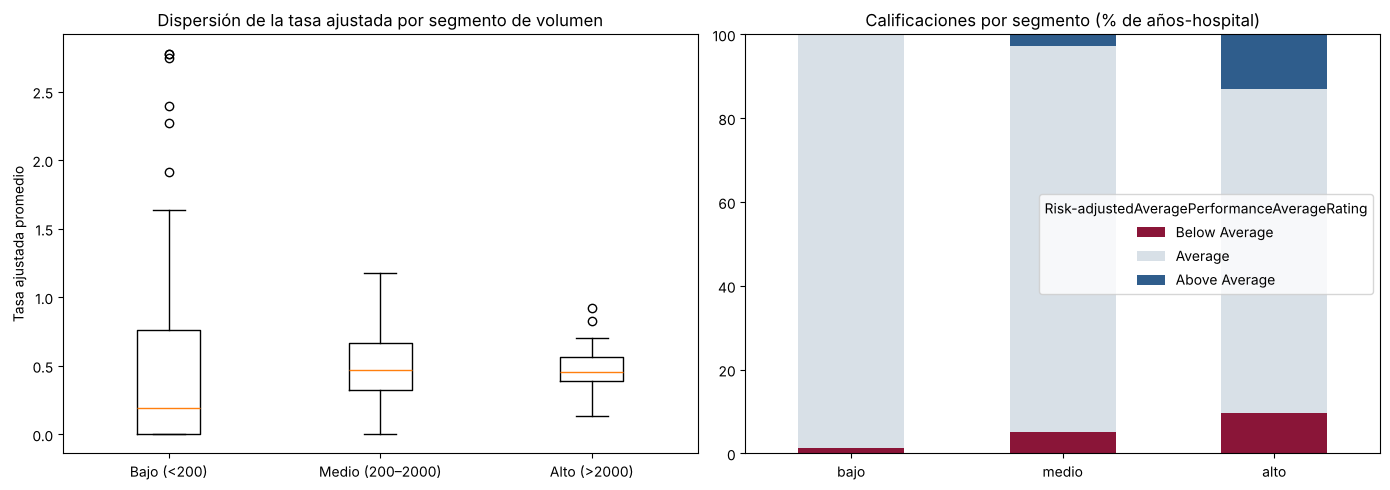

In [48]:
# ── Dispersión de la tasa y calificaciones por segmento de volumen ─────────
orden_seg = ['bajo', 'medio', 'alto']

resumen_seg = persistencia.groupby('segmento').agg(
    hospitales=('OSHPDID', 'count'),
    tasa_media=('tasa', 'mean'),
    desvio_tasa=('tasa', 'std'),
    casos_sepsis=('sepsis_total', 'sum')
).loc[orden_seg]
resumen_seg['%_casos'] = (resumen_seg['casos_sepsis'] / resumen_seg['casos_sepsis'].sum() * 100).round(1)
print(resumen_seg.round(3))

print("\nHospitales con tasa promedio ≤ 0,04:", (persistencia['tasa'] <= 0.04).sum(),
      "| de bajo volumen:", ((persistencia['tasa'] <= 0.04) & (persistencia['segmento'] == 'bajo')).sum())
print("Hospitales con tasa promedio > 1,20:", (persistencia['tasa'] > 1.20).sum(),
      "| de bajo volumen:", ((persistencia['tasa'] > 1.20) & (persistencia['segmento'] == 'bajo')).sum())

# Años-hospital con tasa exactamente cero y distribución de calificaciones por segmento
df_seg = df.merge(persistencia[['OSHPDID', 'segmento']], on='OSHPDID')
ceros = df_seg.groupby('segmento')['Risk-adjusted Postoperative Sepsis Rate'].apply(lambda s: (s == 0).mean() * 100)
print("\n% de años-hospital con tasa = 0:")
print(ceros.loc[orden_seg].round(1))

calif = pd.crosstab(df_seg['segmento'], df_seg['Risk-adjustedAveragePerformanceAverageRating'],
                    normalize='index').loc[orden_seg] * 100
print("\n% de calificaciones por segmento (años-hospital):")
print(calif.round(1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
datos_box = [persistencia.loc[persistencia['segmento'] == s, 'tasa'] for s in orden_seg]
ax1.boxplot(datos_box)
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(['Bajo (<200)', 'Medio (200–2000)', 'Alto (>2000)'])
ax1.set_title('Dispersión de la tasa ajustada por segmento de volumen')
ax1.set_ylabel('Tasa ajustada promedio')

calif[['Below Average', 'Average', 'Above Average']].plot(
    kind='bar', stacked=True, ax=ax2, color=['#8A1538', '#D8E0E7', '#2F5D8C'], rot=0)
ax2.set_title('Calificaciones por segmento (% de años-hospital)')
ax2.set_xlabel('')
plt.tight_layout()
plt.show()

### Lectura

- La tasa de los hospitales de **bajo volumen** tiene un desvío de **0,65**, frente a 0,26 en volumen medio y 0,17 en alto volumen: es **3,8 veces más dispersa** que en los grandes centros.
- En los hospitales de bajo volumen, el **75,6 %** de los años registra tasa = 0.
- Esos hospitales casi nunca reciben una calificación distinta de Average: **0 %** Above Average y **1,3 %** Below Average. En los de alto volumen, en cambio, hay 12,9 % Above y 9,7 % Below.

Esto no demuestra que los hospitales chicos sean mejores ni peores. Muestra que, con pocos eventos, **el indicador anual no tiene información suficiente para distinguirlos**: para ellos, "Average" significa en muchos casos "sin evidencia suficiente". Ese hallazgo respalda la propuesta de usar una tasa trienal en el segmento de bajo volumen.

## Comparativa de modelos de regresión — ¿el volumen explica la tasa?

Para cumplir el mismo criterio en la parte de regresión, se comparan cuatro modelos con validación cruzada de 5 folds (los mismos cortes que en la validación de la cúpula): un **baseline** que predice siempre la media, la regresión **lineal** sobre volumen, la **lineal** sobre log(volumen) y la **polinómica de grado 2** sobre log(volumen).

Métricas: R² en muestra, R² en validación cruzada, MAE y RMSE (error medio, en puntos de tasa).

In [49]:
# ── Comparativa de modelos de regresión ───────────────────────────────────
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score

datos_reg = persistencia[['volumen', 'tasa']].dropna().copy()
datos_reg['log_volumen'] = np.log1p(datos_reg['volumen'])

modelos_reg = [
    ('Baseline (media)', DummyRegressor(), ['volumen']),
    ('Lineal · volumen', LinearRegression(), ['volumen']),
    ('Lineal · log(volumen)', LinearRegression(), ['log_volumen']),
    ('Polinómica grado 2 · log(volumen)', make_pipeline(PolynomialFeatures(degree=2), LinearRegression()), ['log_volumen']),
]

filas_reg = []
for nombre, modelo, columnas in modelos_reg:
    res = cross_validate(modelo, datos_reg[columnas], datos_reg['tasa'], cv=5,
                         scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error',
                                  'rmse': 'neg_root_mean_squared_error'})
    modelo.fit(datos_reg[columnas], datos_reg['tasa'])
    r2_muestra = r2_score(datos_reg['tasa'], modelo.predict(datos_reg[columnas]))
    filas_reg.append({'modelo': nombre, 'R2_muestra': r2_muestra,
                      'R2_CV': res['test_r2'].mean(), 'desvío_R2_CV': res['test_r2'].std(),
                      'MAE_CV': -res['test_mae'].mean(), 'RMSE_CV': -res['test_rmse'].mean()})

print(pd.DataFrame(filas_reg).round(4).to_string(index=False))

                           modelo  R2_muestra   R2_CV  desvío_R2_CV  MAE_CV  RMSE_CV
                 Baseline (media)      0.0000 -0.0336        0.0403  0.2970   0.4220
                 Lineal · volumen      0.0000 -0.0392        0.0407  0.2973   0.4231
            Lineal · log(volumen)      0.0107 -0.0227        0.0358  0.2935   0.4211
Polinómica grado 2 · log(volumen)      0.0436  0.0012        0.0177  0.2848   0.4162


### Lectura

Ningún modelo basado en el volumen supera de forma relevante al baseline que predice siempre la media. La polinómica es la mejor (R² CV 0,0012; MAE 0,285 frente a 0,297 del baseline), pero la mejora es de apenas 0,012 puntos de tasa. **El volumen, por sí solo, no explica la tasa ajustada**: la conclusión de la versión anterior se sostiene con la comparativa formal.

## Cuantificación del valor — priorización de auditorías

Se compara la carga de trabajo de dos reglas de auditoría sobre la ventana 2019–2023:

- **Regla anual (benchmark):** auditar en profundidad cada calificación Below Average de cada año.
- **Regla de persistencia (propuesta):** auditoría en profundidad solo para hospitales con 3 o más años Below Average (crónicos), con seguimiento documental de los episodios ocasionales.

In [50]:
# ── Cuantificación del valor: regla anual vs. regla de persistencia ───────────
calificaciones_below = df['is_below'].sum()
hospitales_con_below = (persistencia['below_years'] > 0).sum()
cronicos = persistencia[persistencia['grupo'] == 'cronico_below']
ocasionales = persistencia[persistencia['grupo'] == 'ocasional_below']
casos_totales = persistencia['sepsis_total'].sum()

print(f"Calificaciones Below Average 2019–2023 (regla anual): {calificaciones_below}")
print(f"Hospitales distintos con al menos un Below Average:     {hospitales_con_below}")
print(f"Hospitales con patrón crónico (3–5 años):               {len(cronicos)}")
print(f"Reducción de auditorías en profundidad:                 "
      f"{(1 - len(cronicos) / calificaciones_below) * 100:.1f} %")
print(f"\nCasos de sepsis en hospitales crónicos:   {cronicos['sepsis_total'].sum()} "
      f"({cronicos['sepsis_total'].sum() / casos_totales * 100:.1f} % del total)")
print(f"Casos de sepsis en hospitales ocasionales: {ocasionales['sepsis_total'].sum()} "
      f"({ocasionales['sepsis_total'].sum() / casos_totales * 100:.1f} % del total)")

bajo = persistencia[persistencia['segmento'] == 'bajo']
print(f"\nHospitales de bajo volumen: {len(bajo)} ({len(bajo) / len(persistencia) * 100:.1f} % de los hospitales)")
print(f"Casos de sepsis en bajo volumen: {bajo['sepsis_total'].sum()} "
      f"({bajo['sepsis_total'].sum() / casos_totales * 100:.1f} % del total)")

Calificaciones Below Average 2019–2023 (regla anual): 65
Hospitales distintos con al menos un Below Average:     45
Hospitales con patrón crónico (3–5 años):               5
Reducción de auditorías en profundidad:                 92.3 %

Casos de sepsis en hospitales crónicos:   509 (9.0 % del total)
Casos de sepsis en hospitales ocasionales: 1634 (28.9 % del total)

Hospitales de bajo volumen: 106 (34.0 % de los hospitales)
Casos de sepsis en bajo volumen: 152 (2.7 % del total)


### Hospitales de referencia del índice de persistencia

Para el anexo del informe se listan los hospitales con patrón crónico Below Average y los de Above Average persistente, con su volumen promedio, su tasa promedio y sus casos acumulados.

In [51]:
# ── Hospitales de referencia: crónicos Below y Above persistentes ──────────
referencia = persistencia[persistencia['grupo'].isin(['cronico_below', 'cronico_above'])].copy()
referencia['años'] = np.where(referencia['grupo'] == 'cronico_below',
                              referencia['below_years'], referencia['above_years'])
referencia = referencia.sort_values(['grupo', 'años', 'volumen'], ascending=[False, False, False])
print(referencia[['nombre', 'grupo', 'años', 'volumen', 'tasa', 'sepsis_total']]
      .round({'volumen': 0, 'tasa': 2}).to_string(index=False))

                                       nombre         grupo  años  volumen  tasa  sepsis_total
                  Cedars-Sinai Medical Center cronico_below     5   6756.0  0.83           329
             Alta Bates Summit Medical Center cronico_below     4   1198.0  0.99            59
                       Scripps Mercy Hospital cronico_below     3   2468.0  0.92            70
                           Dominican Hospital cronico_below     3    556.0  1.18            35
                 Sutter Solano Medical Center cronico_below     3    402.0  1.08            16
Kaiser Foundation Hospital  Oakland/Richmond cronico_above     4   2639.0  0.24            47
         Loma Linda University Medical Center cronico_above     3   3226.0  0.27            53
      Kaiser Foundation Hospital  Sacramento cronico_above     3   1881.0  0.23            25


## Conclusión final

El análisis sometió la relación entre volumen quirúrgico y tasa ajustada
a distintas pruebas: correlación, regresión global, regresiones estratificadas
y un modelo polinómico con validación fuera de muestra.

El resultado más consistente no es que el volumen explique la tasa, sino
justamente lo contrario: **el volumen, utilizado de manera aislada, no
predice de forma confiable su variación**. La relación observada inicialmente
en los datos hospital-año se debilita cuando se trabaja a nivel hospital,
y la forma polinómica tampoco se sostiene bajo validación cruzada.

Esto no demuestra que la tasa ajustada pierda validez en los extremos.
Sí muestra que una lectura basada sólo en tamaño institucional es
insuficiente y que los extremos merecen una interpretación prudente,
especialmente cuando faltan variables clínicas de case-mix.

El aporte propio del trabajo es el ***índice de persistencia***, construido
para distinguir un episodio puntual de un patrón repetido en el tiempo.
Puesto a prueba en el árbol, su peso fue menor al esperado: la tasa ajustada
dominó la separación de los segmentos. **No forcé el resultado para defender
la variable que había creado; se respetó fidedignamente lo que los datos mostraron.**

La utilidad del árbol para identificar los segmentos se evalúa por sus
métricas de prueba y validación cruzada, no sólo por la importancia de
variables.

En conjunto, la tasa ajustada sigue siendo la referencia del análisis,
mientras que volumen y persistencia funcionan como dimensiones
complementarias para decidir cuándo una institución merece una revisión
más detallada. El trabajo no reemplaza el indicador: **delimita qué puede
afirmarse con estos datos y dónde hace falta información adicional**.

**Actualización para la entrega final.** La comparativa de seis modelos con el mismo protocolo confirmó el diagnóstico: el baseline marca 0,333 de balanced accuracy y ningún modelo supera 0,60. Se eligió el **árbol balanceado de profundidad 3** (balanced accuracy CV 0,588 ± 0,068; F1 macro en test 0,608), empatado con Random Forest y XGBoost, por ser el único interpretable como reglas. Sus reglas revelan la **firma del denominador pequeño**: los hospitales de bajo volumen se reconocen por tasas en cero o muy altas. Su tasa es 3,8 veces más dispersa que la de los grandes centros, y casi nunca reciben una calificación distinta de Average. Ese hallazgo, sumado al índice de persistencia, sostiene el modelo de auditoría segmentado: las auditorías en profundidad bajan de 65 (regla anual) a 5 hospitales con patrón crónico.